# Time evolution — scalar diagnostics + Δσ_zz profile

Broadens the §10 time loop from `fluidity_single_step.ipynb`. Per timestep, records:

| symbol | meaning | shape |
|---|---|---|
| `t_yr` | model time | scalar |
| `x_trench`, `xi_loc` | trench column, first isostatic column | scalars |
| `Fd_xT` | $N_D(x_T) = \int(\sigma_{xx}-\sigma_{zz})\,dz$ at the trench | scalar |
| `V_xT` | $V(x_T) = \int\tau_{zx}\,dz$ at the trench | scalar |
| `w_T` | $\mathrm{fs}(x_I) - \mathrm{fs}(x_T)$ — topographic recovery between the two columns | scalar |
| `delta_Fd` | $N_D(x_I) - N_D(x_T)$ — column difference of the deviatoric resultant | scalar |
| `delta_GPE` | $\mathrm{GPE}^*(x_I) - \mathrm{GPE}^*(x_T)$ where $\mathrm{GPE}^* = -\int\sigma_{zz}\,dz$ | scalar |
| `delta_sig_zz_z` | $\sigma_{zz}(x_I, z) - \sigma_{zz}(x_T, z)$ — full depth profile | (nz,) |

Conventions match the rest of the repo: x rightward, z downward, model mirrored along x at extraction so subduction is right-to-left.

Outputs are saved to `outputs/time_evolution_<MODEL>.npz`.

## 1. Setup & imports

In [1]:
import numpy as np
if not hasattr(np, 'trapz'): np.trapz = np.trapezoid  # numpy 2.x compat
import glob
import natsort
import matplotlib.pyplot as plt
import pyvista as pv
import warnings, logging, gc
from scipy.integrate import cumulative_trapezoid
from scipy.ndimage import gaussian_filter1d
from pathlib import Path

pv.set_error_output_file(Path('/tmp/vtk_errors.log'))
logging.getLogger('pyvista').setLevel(logging.CRITICAL)
logging.getLogger().setLevel(logging.CRITICAL)
warnings.filterwarnings('ignore', message='The VTK reader .*vtkXMLPUnstructuredGridReader.*')

plt.rcParams.update({'mathtext.fontset': 'cm', 'font.family': 'serif'})

## 2. Configuration

Same setup conventions as the other Cerpa notebooks. `MIRROR_X = True` mirrors the model along x so subduction matches MDOODZ orientation.

In [2]:
DATA_ROOT = '/Users/DSAND/DATA/numerical_models/OUTPUTS/'

MODELS = {
    'STD': dict(folder='STD_RefModel', modname='subduction_with_LM'),
    'WAL': dict(folder='WAL_RefModel', modname='subduction_with_LM'),
}

MODEL_KEY = 'STD'

DX        = 200.0
Z_MAX     = 75_000.0
Y_SURFACE = 2_900_000.0

# Mirror flag and derived directional constants
MIRROR_X        = True
SUBDUCTING_SIDE = 'right' if MIRROR_X else 'left'
SEAWARD_SIGN    = +1     if MIRROR_X else -1

# Isostatic-column picker parameters
BUFFER_KM    = 30           # skip this much of the bend right next to the trench
WINDOW_KM    = 500          # search window seaward of the trench
REGIONAL_REF_KM = 500       # offset of the 'regional' reference column from the trench

fbase   = DATA_ROOT + MODELS[MODEL_KEY]['folder'] + '/'
modname = MODELS[MODEL_KEY]['modname']
pvtu_files = natsort.natsorted(glob.glob(fbase + modname + '*.pvtu'))
print(f"Model {MODEL_KEY!r}: {len(pvtu_files)} PVTU files in {fbase}")
print(f"MIRROR_X = {MIRROR_X}  ->  SUBDUCTING_SIDE = {SUBDUCTING_SIDE!r}, SEAWARD_SIGN = {SEAWARD_SIGN:+d}")

# === Canonical analysis defaults (match cerpa_single_step §2) ================
INTEGRATION_DEPTH_KM = 75              # Depth [km] for vertical σ_zz integrals
SMOOTHWIN            = 10               # ± grid columns averaged around picked columns
TRENCH_REF_HW_KM     = 5                # half-width [km]: uniform ±5 km suite window (conventions §4.1)
WIN_T                = max(1, int(TRENCH_REF_HW_KM * 1000 / DX))   # in grid points
RHO_W                = 0.0              # no water above the surface (Cerpa setup)
rho_m, g             = 3300.0, 9.8      # mantle reference density [kg/m³] and gravity [m/s²]
DEPTH_LIM            = (INTEGRATION_DEPTH_KM, 0)   # default ylim for depth panels

# === Time-evolution-specific knobs ===========================================
T_ISO_K          = 900.0 + 273.15       # = 1173.15 K  ↔  900 °C
Z_NP_FALLBACK    = 30e3                 # neutral-plane fallback if no zero-crossing
RIDGE_BUFFER_KM  = 200                  # outer-rise buffer for find_ridge_x
RIDGE_SMOOTH_KM  = 50                   # surface smoothing for find_ridge_x

# === Output dir ==============================================================
figures_dir = Path("figures"); figures_dir.mkdir(exist_ok=True)


Model 'STD': 41 PVTU files in /Users/DSAND/DATA/numerical_models/OUTPUTS/STD_RefModel/
MIRROR_X = True  ->  SUBDUCTING_SIDE = 'right', SEAWARD_SIGN = +1


## 3. Helpers

- `get_field(name)` — reshapes a sampled VTK array onto the regular grid.
- `mirror_fields_in_x(...)` — applies the x-mirror with sign flips on the off-diagonal stress and x-velocity.
- `pick_trench_3step(...)` — same picker as the other notebooks (pressure → velocity → directional pressure).
- `find_first_isostatic_column(...)` — walks seaward from the trench and returns the index of the first column whose free-surface elevation has recovered to the regional reference.

In [3]:
from cerpa_helpers import (
    make_field_extractor,
    mirror_fields_in_x,
    pick_trench_3step,
    find_first_isostatic_column,
    find_ridge_x,
    col_avg,
    norm01,
    load_records,
)


## 4. Time loop

For each PVTU snapshot: load → mirror → pick trench → find first isostatic column → compute the column quantities → record scalars + the Δσ_zz depth profile.

In [4]:
SECONDS_PER_YEAR = 31_557_600.0

# Load-or-compute guard.  Set FORCE_RECOMPUTE = True to ignore any cached
# npz at NPZ_PATH and rerun the time loop.  Old cached npz files that
# pre-date the `z_iso` column also trigger a recompute.
NPZ_PATH        = Path('outputs') / f'time_evolution_{MODEL_KEY}.npz'
FORCE_RECOMPUTE = False

# Isotherm whose depth we track at the trench column (in Kelvin; PVTU
# field is in K with T_surface = 273, T_mantle = 1573).
T_ISO_K = 900.0 + 273.15        # =
print(T_ISO_K )

# Load-or-compute guard.  Set FORCE_RECOMPUTE = True to ignore any cached
# npz at NPZ_PATH and rerun the time loop.  Old cached npz files that
# pre-date the latest record schema also trigger a recompute.

# Neutral-plane fallback depth (used when no zero-crossing is found in the
# search window).  Same default as the single-step §9 picker.
Z_NP_FALLBACK = 30e3             # 30 km

# Schema check — keys whose presence in the cached npz indicates the
# cache was produced by the current loop body.  Old caches that lack any
# of these trigger a recompute.
REQUIRED_KEYS = ('z_iso', 'h_np', 'xm_loc', 'rloc', 'delta_GPE_R', 'delta_Fd_R',
                 'q_R', 'f_tilt', 'v_sp', 'v_op')


1173.15


In [5]:


_from_cache = False
if NPZ_PATH.exists() and not FORCE_RECOMPUTE:
    d = np.load(NPZ_PATH)
    if all(k in d.files for k in REQUIRED_KEYS):
        z_axis          = d['z']
        delta_sig_zz_zt = d['delta_sig_zz_zt']
        records = {k: d[k] for k in d.files if k not in ('z', 'delta_sig_zz_zt')}
        _from_cache = True
        print(f'loaded cache: {NPZ_PATH}  ({len(records["snapshot"])} snapshots)')
    else:
        missing = [k for k in REQUIRED_KEYS if k not in d.files]
        print(f'cache at {NPZ_PATH} is missing fields {missing}; recomputing')

if not _from_cache:
    records = dict(
        snapshot=[], t_yr=[], x_trench=[], xi_loc=[], xm_loc=[], rloc=[],
        Fd_xT=[], V_xT=[], w_T=[],
        delta_Fd=[], delta_Fd_R=[], delta_GPE=[], delta_GPE_R=[],
        z_iso=[], h_np=[], q_R=[], f_tilt=[], v_sp=[], v_op=[],
    )
    delta_sig_zz_z_list = []
    z_axis = None

    for i, ff in enumerate(pvtu_files[::1]):
        if i == 0:
            continue

        vtk_data = pv.read(ff)
        vtk_data.point_data['p']   = vtk_data['NormalSP::Pressure']
        vtk_data.point_data['txx'] = vtk_data['NormalSP::Stress'][:, 0]
        vtk_data.point_data['tzz'] = vtk_data['NormalSP::Stress'][:, 4]
        vtk_data.point_data['txz'] = -vtk_data['NormalSP::Stress'][:, 1]
        vtk_data.point_data['T']   = vtk_data['NormalSP::Temperature']
        vtk_data.point_data['fs']  = vtk_data['NormalSP::FreeSurface']
        vel = vtk_data['NormalSP::Velocity'] / 3.17098e-10
        vtk_data.point_data['vx']  = vel[:, 0]
        vtk_data.point_data['vy']  = vel[:, 1]

        t_yr = float(np.asarray(vtk_data['NormalSP::Time']).flat[0]) / SECONDS_PER_YEAR

        x_min, x_max, _, _, _, _ = vtk_data.bounds
        nx = int((x_max - x_min) / DX); nz = int(Z_MAX / DX)
        x = x_min + (np.arange(nx) + 0.5) * DX
        z = (np.arange(nz) + 0.5) * DX
        X, Z = np.meshgrid(x, z, indexing='xy')
        Y = Y_SURFACE - Z
        grid = pv.StructuredGrid(X.T, Y.T, np.zeros_like(X.T))
        interp = grid.sample(vtk_data)
        nx_pv, nz_pv, _ = interp.dimensions
        valid = interp['vtkValidPointMask'].reshape((nx_pv, nz_pv), order='F').astype(bool)
        get_field = make_field_extractor(interp, nx_pv, nz_pv, valid)

        p   = get_field('p')
        txx = get_field('txx')
        tzz = get_field('tzz')
        txz = get_field('txz')
        T   = get_field('T')
        fs  = get_field('fs')
        vx  = get_field('vx')
        vz  = -get_field('vy')

        if MIRROR_X:
            p, txx, tzz, txz, T, fs, vx, vz = mirror_fields_in_x(p, txx, tzz, txz, T, fs, vx, vz)

        if z_axis is None:
            z_axis = z.copy()

        try:
            x_trench, _ = pick_trench_3step(
                x, z, p, vx,
                vx_depth_m=2000, Wp1_km=800, Wv_km=800, Wp3_km=500,
                smooth_km=30, subducting_side=SUBDUCTING_SIDE,
            )
        except Exception as e:
            print(f'  [{i}] picker failed: {e}; skipping')
            continue
        tindx = int(np.argmin(np.abs(x - x_trench)))

        xi_indx, _ = find_first_isostatic_column(
            x, fs[0, :], x_trench, tindx, DX,
            buffer_km=BUFFER_KM, window_km=WINDOW_KM,
            regional_ref_km=REGIONAL_REF_KM, seaward_sign=SEAWARD_SIGN,
        )
        xi_loc  = float(x[xi_indx])
        
        #xm_loc  = 0.5 * (x_trench + xi_loc)
        #xm_indx = int(np.argmin(np.abs(x - xm_loc)))

        # x_M: maximum-bending-moment location.  First zero-crossing of V(x) seaward                                                                                            
        # of the trench, where V(x) = ∫₀^{z_c} τ_zx dz.  Use V_smooth if it's already
        # in scope (single-step §7 computes it); otherwise smooth on the fly so a                                                                                               
        # noise spike near zero can't pose as a real crossing.                                                                                                                  
        try:                                                                                                                                                                    
            V_for_xm = V_smooth                                                                                                                                                 
        except NameError:                                                                                                                                                       
            V_x      = np.trapz(txz, z, axis=0)                                                                                                                                 
            V_for_xm = gaussian_filter1d(V_x, sigma=10, mode='nearest')                                                                                                         
        XM_BUFFER_KM = 5                                                                                                                                                        
        buffer_m = XM_BUFFER_KM * 1000.0                          
        seaward = (x > x_trench + buffer_m) if SEAWARD_SIGN > 0 else (x < x_trench - buffer_m)                                                                                                                                                                                                                                                            
        xs, Vs = x[seaward], V_for_xm[seaward]                                                                                                                                  
        if SEAWARD_SIGN < 0:                                                                                                                                                    
            xs, Vs = xs[::-1], Vs[::-1]                                                                                                                                                                                        
        cross = np.where(Vs[:-1] * Vs[1:] < 0)[0]
        if cross.size > 0:                                                                                                                                                      
            k = cross[0]                                          
            xm_loc = float(xs[k] - Vs[k] * (xs[k+1] - xs[k]) / (Vs[k+1] - Vs[k]))
        else:                                                                                                                                                                   
            xm_loc = 0.5 * (x_trench + xi_loc)
            print("⚠  no V=0 crossing seaward of trench; falling back to (x_T + x_I)/2")                                                                                        
                                                                  
        xm_indx = int(np.argmin(np.abs(x - xm_loc)))

        # Ridge column (highest free-surface point seaward of trench)
        try:
            rloc, rindx = find_ridge_x(
                x, fs[0, :], x_trench, seaward_sign=SEAWARD_SIGN,
                buffer_km=RIDGE_BUFFER_KM, smooth_km=RIDGE_SMOOTH_KM,
            )
        except RuntimeError as e:
            print(f'  [{i}] ridge-finder failed: {e}; skipping')
            continue

        # plate-interior velocities (§7.3): medians far from the axis zone.
        # NOTE the /3.17098e-10 conversion above makes vx numerically cm/yr
        # (kept as-is for cache continuity; label accordingly).
        zi_v = (z > 10e3) & (z < 40e3)
        sp_box = (x > xi_loc + 500e3) & (x < rloc - 500e3)
        op_box = (x > x_trench - 1500e3) & (x < x_trench - 500e3)
        v_sp = float(np.nanmedian(vx[np.ix_(zi_v, sp_box)]))
        v_op = float(np.nanmedian(vx[np.ix_(zi_v, op_box)]))

        # --- back-tilt deep band (ANALYSIS_CONVENTIONS §6b) -----------------
        # Coarse sample of the declared 120-190 km band; q_c = deep sigma_zz
        # residual rel. the x_I column (±25 km, 100-km smoothed);
        # F_tilt = -q_c(x_R) * z_c.  Same construction as the aspect repo.
        nxd = int((x_max - x_min) / 1000.0)
        xd = x_min + (np.arange(nxd) + 0.5) * 1000.0
        zd = 120e3 + (np.arange(70) + 0.5) * 1000.0
        Xd, Zd = np.meshgrid(xd, zd, indexing='xy')
        gridd = pv.StructuredGrid(Xd.T, (Y_SURFACE - Zd).T, np.zeros_like(Xd.T))
        interpd = gridd.sample(vtk_data)
        nxd_pv, nzd_pv, _ = interpd.dimensions
        validd = interpd['vtkValidPointMask'].reshape((nxd_pv, nzd_pv), order='F').astype(bool)
        szz_deep = (interpd['tzz'].reshape((nxd_pv, nzd_pv), order='F').astype(float)
                    - interpd['p'].reshape((nxd_pv, nzd_pv), order='F').astype(float))
        szz_deep[~validd] = np.nan
        szz_deep = np.nanmean(szz_deep.T, axis=0)
        if MIRROR_X:
            szz_deep = szz_deep[::-1]
        iId = int(np.argmin(np.abs(xd - xi_loc)))
        iRd = int(np.argmin(np.abs(xd - rloc)))
        q_prof = gaussian_filter1d(
            -(szz_deep - np.mean(szz_deep[max(0, iId - 25):iId + 26])), 100)
        q_R = float(np.mean(q_prof[max(0, iRd - 25):iRd + 26]))
        f_tilt = -q_R * INTEGRATION_DEPTH_KM * 1e3
        del gridd, interpd

        Fd_x   = np.trapz(txx - tzz, z, axis=0)
        V_x    = np.trapz(txz, z, axis=0)
        GPE_x  = -np.trapz(-p + tzz, z, axis=0)
        sig_zz = -p + tzz

        Fd_xT       = float(Fd_x[tindx])
        V_xT        = float(V_x[tindx])
        w_T         = float(fs[0, xi_indx] - fs[0, tindx])
        delta_Fd    = float(Fd_x[xi_indx]  - Fd_x[tindx])
        delta_Fd_R  = float(Fd_x[rindx]    - Fd_x[tindx])     # ridge-to-trench
        delta_GPE   = float(GPE_x[xi_indx] - GPE_x[tindx])
        delta_GPE_R = float(GPE_x[rindx]   - GPE_x[tindx])     # ridge-to-trench

        delta_sig_zz_z = sig_zz[:, xi_indx] - sig_zz[:, tindx]

        # Depth to T_ISO_K at the trench column — first crossing from above.
        T_col = T[:, tindx]
        diff  = T_col - T_ISO_K
        idx   = np.where(diff[:-1] * diff[1:] < 0)[0]
        if idx.size > 0:
            k = idx[0]
            z_iso = float(z[k] + (T_ISO_K - T_col[k]) * (z[k+1] - z[k])
                                  / (T_col[k+1] - T_col[k]))
        else:
            z_iso = float('nan')

        # Neutral-plane depth at the midpoint column x_M
        diff_xm = txx[:, xm_indx] - tzz[:, xm_indx]
        z_lo, z_hi = 10e3, 50e3
        i_zlo = int(np.argmin(np.abs(z - z_lo)))
        i_zhi = int(np.argmin(np.abs(z - z_hi)))
        sc = []
        for k in range(i_zlo, i_zhi):
            if diff_xm[k] * diff_xm[k+1] < 0:
                sc.append(k)
        if len(sc) > 0:
            k = sc[0]
            h_np = float(z[k] - diff_xm[k] * (z[k+1] - z[k])
                                / (diff_xm[k+1] - diff_xm[k]))
        else:
            h_np = Z_NP_FALLBACK

        records['snapshot'].append(i)
        records['t_yr'].append(t_yr)
        records['x_trench'].append(x_trench)
        records['xi_loc'].append(xi_loc)
        records['xm_loc'].append(xm_loc)
        records['rloc'].append(rloc)
        records['Fd_xT'].append(Fd_xT)
        records['V_xT'].append(V_xT)
        records['w_T'].append(w_T)
        records['delta_Fd'].append(delta_Fd)
        records['delta_Fd_R'].append(delta_Fd_R)
        records['delta_GPE'].append(delta_GPE)
        records['delta_GPE_R'].append(delta_GPE_R)
        records['z_iso'].append(z_iso)
        records['h_np'].append(h_np)
        records['q_R'].append(q_R)
        records['f_tilt'].append(f_tilt)
        records['v_sp'].append(v_sp)
        records['v_op'].append(v_op)
        delta_sig_zz_z_list.append(delta_sig_zz_z)

        del vtk_data, grid, interp, X, Y, Z, p, txx, tzz, txz, T, fs, vx, vz
        if i % 5 == 0:
            gc.collect()

    for k in records:
        records[k] = np.asarray(records[k])
    delta_sig_zz_zt = np.vstack(delta_sig_zz_z_list)

    print(f'\n[{MODEL_KEY}] processed {len(records["snapshot"])} snapshots')
    print(f'    t           = {records["t_yr"].min()/1e6:6.2f} -> {records["t_yr"].max()/1e6:6.2f} Myr')
    print(f'    N_D(x_T)    = {records["Fd_xT"].min()*1e-12:+6.2f}  to {records["Fd_xT"].max()*1e-12:+6.2f} TN/m')
    print(f'    V(x_T)      = {records["V_xT"].min()*1e-12:+6.2f}  to {records["V_xT"].max()*1e-12:+6.2f} TN/m')
    print(f'    w_T         = {records["w_T"].min():+6.0f}  to {records["w_T"].max():+6.0f}  m')
    print(f'    Δ N_D       = {records["delta_Fd"].min()*1e-12:+6.2f}  to {records["delta_Fd"].max()*1e-12:+6.2f} TN/m')
    print(f'    Δ N_D   (R) = {records["delta_Fd_R"].min()*1e-12:+6.2f}  to {records["delta_Fd_R"].max()*1e-12:+6.2f} TN/m   (ridge - trench)')
    print(f'    delta_GPE   (I) = {records["delta_GPE"].min()*1e-12:+6.2f}  to {records["delta_GPE"].max()*1e-12:+6.2f} TN/m')
    print(f'    delta_GPE_R (R) = {records["delta_GPE_R"].min()*1e-12:+6.2f}  to {records["delta_GPE_R"].max()*1e-12:+6.2f} TN/m   (ridge - trench)')
    print(f'    rloc        = {records["rloc"].min()/1e3:6.0f}  to {records["rloc"].max()/1e3:6.0f} km')
    print(f'    z_iso       = {np.nanmin(records["z_iso"])/1e3:6.1f}  to {np.nanmax(records["z_iso"])/1e3:6.1f} km   (T = {T_ISO_K-273.15:.0f}°C)')
    print(f'    h_np        = {records["h_np"].min()/1e3:6.1f}  to {records["h_np"].max()/1e3:6.1f} km   (neutral plane at x_M)')


loaded cache: outputs/time_evolution_STD.npz  (20 snapshots)


## 5. Persist to npz

In [6]:
NPZ_PATH.parent.mkdir(exist_ok=True)

if not _from_cache:
    np.savez(NPZ_PATH, z=z_axis, delta_sig_zz_zt=delta_sig_zz_zt, **records)
    print(f'saved -> {NPZ_PATH}')
else:
    print(f'loaded from cache; save skipped ({NPZ_PATH.name})')


loaded from cache; save skipped (time_evolution_STD.npz)


## 6. Load cached records (multi-model)

Reads `outputs/time_evolution_<MODEL_KEY>.npz` for both models and binds
`records_STD` and `records_WAL` for use by every figure that follows.  Run §4
once with `MODEL_KEY = "STD"` and once with `MODEL_KEY = "WAL"` to populate
both caches before running this cell.


In [7]:
records_STD = load_records('STD')
records_WAL = load_records('WAL')

if records_STD is not None:
    print(f"records_STD: {len(records_STD['snapshot'])} snapshots, "
          f"t = {records_STD['t_yr'].min()/1e6:.1f} → {records_STD['t_yr'].max()/1e6:.1f} Myr")
if records_WAL is not None:
    print(f"records_WAL: {len(records_WAL['snapshot'])} snapshots, "
          f"t = {records_WAL['t_yr'].min()/1e6:.1f} → {records_WAL['t_yr'].max()/1e6:.1f} Myr")


records_STD: 20 snapshots, t = 4.0 → 80.0 Myr
records_WAL: 20 snapshots, t = 4.0 → 79.9 Myr


## 7. Multi-model figures (from cached records)

Slide-grade figures comparing STD and WAL.  Each cell uses `records_STD`
and `records_WAL` from §6 directly — no per-cell loading.  Output PNGs
go to `figures/` with neutral filenames (no `MODEL_KEY` suffix) since
both models appear in every figure.


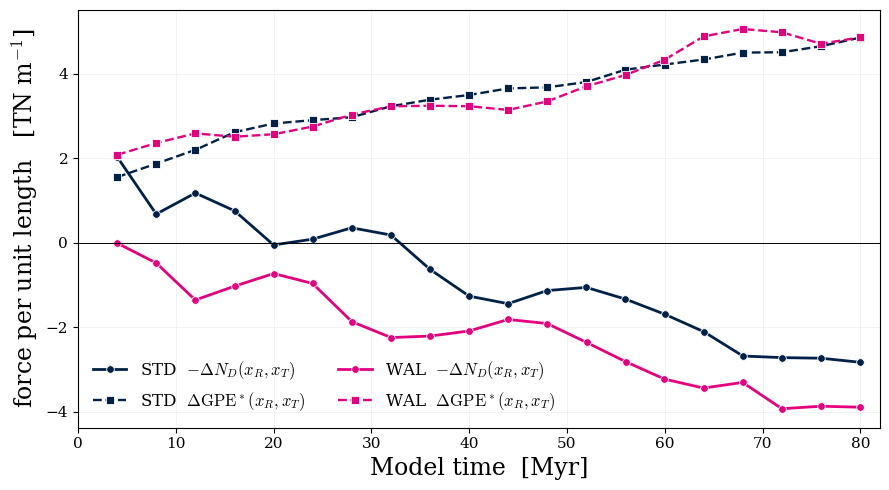

In [8]:
# time-series of \Delta\mathrm{GPE}^*(x_R, x_T) and -ΔF_D(x_R, x_T) for STD and WAL.
# Same brand styling as the Fd_xT slide-figure: large fonts, brand colours,
# rule grid, white marker edges.  Note: -ΔF_D is now the primary (bold solid)
# curve and \Delta\mathrm{GPE}^* is the comparison (dashed) curve — swapped from the previous
# version.
figures_dir.mkdir(exist_ok=True)

# Brand palette (matches presentation/theme.scss)
C_STD, C_WAL            = "#002147", "#E5007D"
C_SLATE, C_RULE, C_BAND = "#404B74", "#BFC3D1", "#F2F3F5"
models = [
    ("STD", C_STD, records_STD),
    ("WAL",     C_WAL, records_WAL),
]

fig, ax = plt.subplots(figsize=(9, 5))

for label, color, rec in models:
    if rec is None:
        continue
    t_Myr = rec["t_yr"] / 1e6

    # -ΔF_D(x_R, x_T) — bold solid, the primary curve
    ax.plot(t_Myr, -rec["delta_Fd_R"] * 1e-12,
            "-o", color=color, lw=2.0, ms=5.5,
            markeredgecolor="white", markeredgewidth=0.6,
            label=fr"{label}  $-\Delta N_D(x_R, x_T)$")

    # \Delta\mathrm{GPE}^*(x_R, x_T) — dashed, the comparison curve
    ax.plot(t_Myr, rec["delta_GPE_R"] * 1e-12,
            "--s", color=color, lw=1.7, ms=5.5,
            markeredgecolor="white", markeredgewidth=0.6,
            label=fr"{label}  $\Delta\mathrm{{GPE}}^*(x_R, x_T)$")

ax.axhline(0, color="k", lw=0.7)

ax.set_xlabel("Model time  [Myr]", fontsize=17)
ax.set_ylabel(r"force per unit length   [TN m$^{-1}$]", fontsize=17)
ax.set_xlim(0, 82)
ax.legend(loc="best", frameon=False, fontsize=12, ncol=2)
ax.grid(True, alpha=0.25, color=C_RULE, lw=0.6)
ax.tick_params(labelsize=11)

fig.tight_layout()
fig.savefig(figures_dir / "delta_GPE_R_delta_Fd_R_time_series.png",
            bbox_inches="tight", dpi=220)
plt.show()

**Interpretation**

* $\Delta\mathrm{GPE}^*$ is the **only consistently driving term**, rising from ~2 to ~5 TN/m as the plate ages and its topography grows. $F_B$ is uniformly resisting (~1–3 TN/m).
* $\Delta N_D$ starts near neutral (STD briefly driving early on) and then spends **most of both runs resisting** — increasingly so with time. The normal-stress-difference resultant opposes the plate's motion for the majority of the history: the reverse of the slab-pull reading, and the normal state of these models.

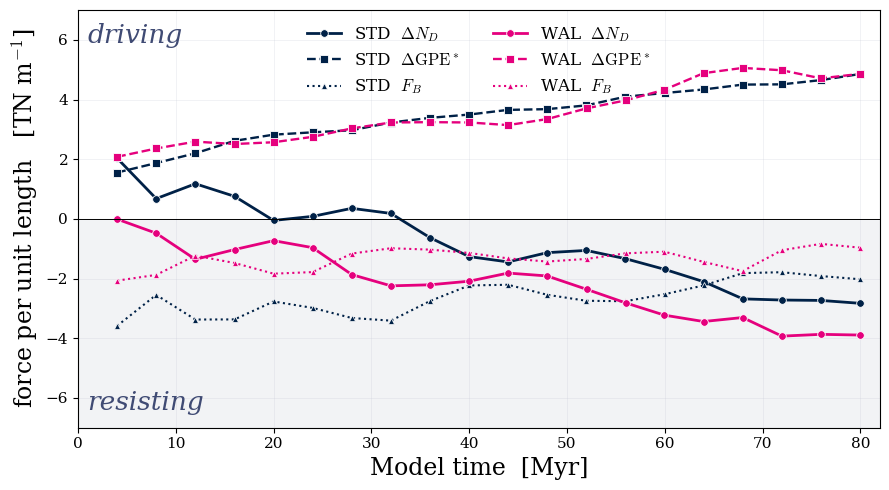

In [9]:
# time-series of -ΔF_D, \Delta\mathrm{GPE}^*, and the basal-drag residual F_B
# (all ridge-to-trench column differences) for STD and WAL.
figures_dir.mkdir(exist_ok=True)

# Brand palette (matches presentation/theme.scss)
C_STD, C_WAL            = "#002147", "#E5007D"
C_SLATE, C_RULE, C_BAND = "#404B74", "#BFC3D1", "#F2F3F5"
models = [
    ("STD", C_STD, records_STD),
    ("WAL", C_WAL, records_WAL),
]

fig, ax = plt.subplots(figsize=(9, 5))

for label, color, rec in models:
    if rec is None:
        continue
    t_Myr = rec["t_yr"] / 1e6

    # -ΔF_D — bold solid, primary
    ax.plot(t_Myr, -rec["delta_Fd_R"] * 1e-12,
            "-o", color=color, lw=2.0, ms=5.5,
            markeredgecolor="white", markeredgewidth=0.6,
            label=fr"{label}  $\Delta N_D$")

    # \Delta\mathrm{GPE}^* — dashed, comparison
    ax.plot(t_Myr, rec["delta_GPE_R"] * 1e-12,
            "--s", color=color, lw=1.7, ms=5.5,
            markeredgecolor="white", markeredgewidth=0.6,
            label=fr"{label}  $\Delta\mathrm{{GPE}}^*$")

    # Basal-drag residual: F_B = ΔF_D - \Delta\mathrm{GPE}^*  (sign flipped from the
    # previous version so the residual sits in the "resisting" half)
    F_B_R = (rec["delta_Fd_R"] - rec["delta_GPE_R"]) * 1e-12
    ax.plot(t_Myr, F_B_R,
            ":^", color=color, lw=1.5, ms=5.0,
            markeredgecolor="white", markeredgewidth=0.5,
            label=fr"{label}  $F_B$")

ax.axhline(0, color="k", lw=0.7)
ax.axhspan(-100, 0, color=C_BAND, zorder=-2)
ax.text(0.012, 0.97, "driving", transform=ax.transAxes,
        ha="left", va="top", fontsize=19, color=C_SLATE, style="italic")
ax.text(0.012, 0.03, "resisting", transform=ax.transAxes,
        ha="left", va="bottom", fontsize=19, color=C_SLATE, style="italic")

ax.set_xlabel("Model time  [Myr]", fontsize=17)
ax.set_ylabel(r"force per unit length   [TN m$^{-1}$]", fontsize=17)
ax.set_xlim(0, 82)
ax.set_ylim(-7, 7)
ax.legend(loc="upper center", frameon=False, fontsize=12, ncol=2)
ax.grid(True, alpha=0.25, color=C_RULE, lw=0.6)
ax.tick_params(labelsize=11)

fig.tight_layout()
fig.savefig(figures_dir / "delta_GPE_R_delta_Fd_R_time_series.png",
            bbox_inches="tight", dpi=220)
plt.show()

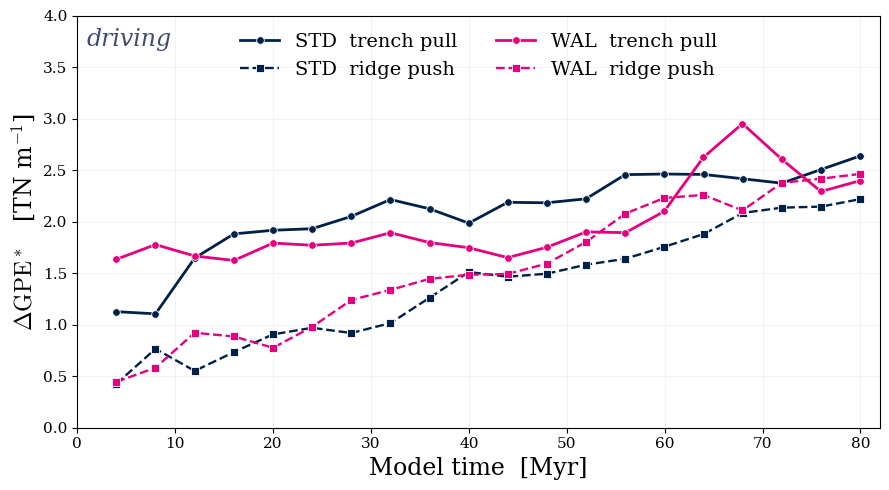

In [10]:
# Decompose \Delta\mathrm{GPE}^*(x_R, x_T) — the full ridge-to-trench column-GPE difference —
# into its two regimes:
#
#   trench pull   \Delta\mathrm{GPE}^*(x_I, x_T) = \mathrm{GPE}^*(x_I) - \mathrm{GPE}^*(x_T)   (records['delta_GPE'])
#   ridge push    \Delta\mathrm{GPE}^*(x_R, x_I) = \mathrm{GPE}^*(x_R) - \mathrm{GPE}^*(x_I)   (delta_GPE_R - delta_GPE)
#   total         \Delta\mathrm{GPE}^*(x_R, x_T) = \mathrm{GPE}^*(x_R) - \mathrm{GPE}^*(x_T)   (records['delta_GPE_R'])
#
# By construction, total = trench pull + ridge push.
figures_dir.mkdir(exist_ok=True)

# Brand palette
C_STD, C_WAL            = "#002147", "#E5007D"
C_SLATE, C_RULE, C_BAND = "#404B74", "#BFC3D1", "#F2F3F5"
models = [
    ("STD", C_STD, records_STD),
    ("WAL", C_WAL, records_WAL),
]

fig, ax = plt.subplots(figsize=(9, 5))

for label, color, rec in models:
    if rec is None:
        continue
    t_Myr = rec["t_yr"] / 1e6

    dGPE_total = rec["delta_GPE_R"]                       # ridge to trench (total)
    dGPE_TP    = rec["delta_GPE"]                          # isostatic to trench (trench pull)
    dGPE_RP    = rec["delta_GPE_R"] - rec["delta_GPE"]     # ridge to isostatic (ridge push)

    # Trench pull — bold solid
    ax.plot(t_Myr, dGPE_TP * 1e-12,
            "-o", color=color, lw=2.0, ms=5.5,
            markeredgecolor="white", markeredgewidth=0.6,
            label=fr"{label}  trench pull")

    # Ridge push — dashed
    ax.plot(t_Myr, dGPE_RP * 1e-12,
            "--s", color=color, lw=1.7, ms=5.5,
            markeredgecolor="white", markeredgewidth=0.6,
            label=fr"{label}  ridge push")

    # Total — dotted, lighter
    #ax.plot(t_Myr, dGPE_total * 1e-12,
    #        ":^", color=color, lw=1.5, ms=5.0,
    #        markeredgecolor="white", markeredgewidth=0.5,
    #        label=fr"{label}  total")

ax.axhline(0, color="k", lw=0.7)
ax.axhspan(-100, 0, color=C_BAND, zorder=-2)
ax.text(0.012, 0.97, "driving", transform=ax.transAxes,
        ha="left", va="top", fontsize=17, color=C_SLATE, style="italic")
#ax.text(0.012, 0.03, "resisting", transform=ax.transAxes,
#        ha="left", va="bottom", fontsize=17, color=C_SLATE, style="italic")

ax.set_xlabel("Model time  [Myr]", fontsize=17)
ax.set_ylabel(r"$\Delta\mathrm{GPE}^*$   [TN m$^{-1}$]", fontsize=17)
ax.set_xlim(0, 82)
ax.set_ylim(0, 4)
ax.legend(loc="upper center", frameon=False, fontsize=14, ncol=2)
ax.grid(True, alpha=0.25, color=C_RULE, lw=0.6)
ax.tick_params(labelsize=11)

fig.tight_layout()
fig.savefig(figures_dir / "GPE_decomposition_time_series.png",
            bbox_inches="tight", dpi=220)
plt.show()


**Interpretation**

* The total $\Delta\mathrm{GPE}^*$ splits into non-overlapping **trench pull** and **ridge push** components sharing the first isostatic column $x_I$ as their common reference.
* Trench pull dominates early (roughly 3× ridge push in the first ~10 Myr); ridge push grows steadily as the plate cools and its isostatic topography builds, and the two become comparable by the end of the run — consistent with plate age at the trench more than doubling over the model duration.

### The driving-force partition with the back-tilt force

Per `ANALYSIS_CONVENTIONS.md` §6b (single-step anatomy in
`further_analysis/fluidity_back_tilt.ipynb`): trench pull
$\Delta\mathrm{GPE}^*(x_I, x_T)$, measured ridge push
$\Delta\mathrm{GPE}^*(x_R, x_I)$, and the **back-tilt force**
$F_{tilt} = -q_c(x_R)\,z_c$ — the ridge push *suppressed* by the
asthenospheric return-flow gradient tilting the plate down toward the ridge
($q_c$: deep σ_zz residual rel. the $x_I$ column, 120–190 km band, 100-km
smoothed). It can move over to measured ridge push as the channel evolves;
isostatic ridge push = measured + $F_{tilt}$. **STD vs WAL is the controlled
experiment**: only the weak asthenospheric layer differs.

STD: run-median  trench pull +2.18, RP meas +1.48, F_tilt +0.65 TN/m, suppression 0.29
WAL: run-median  trench pull +1.79, RP meas +1.49, F_tilt +0.33 TN/m, suppression 0.17
figure: figures/partition_back_tilt_time_series.png


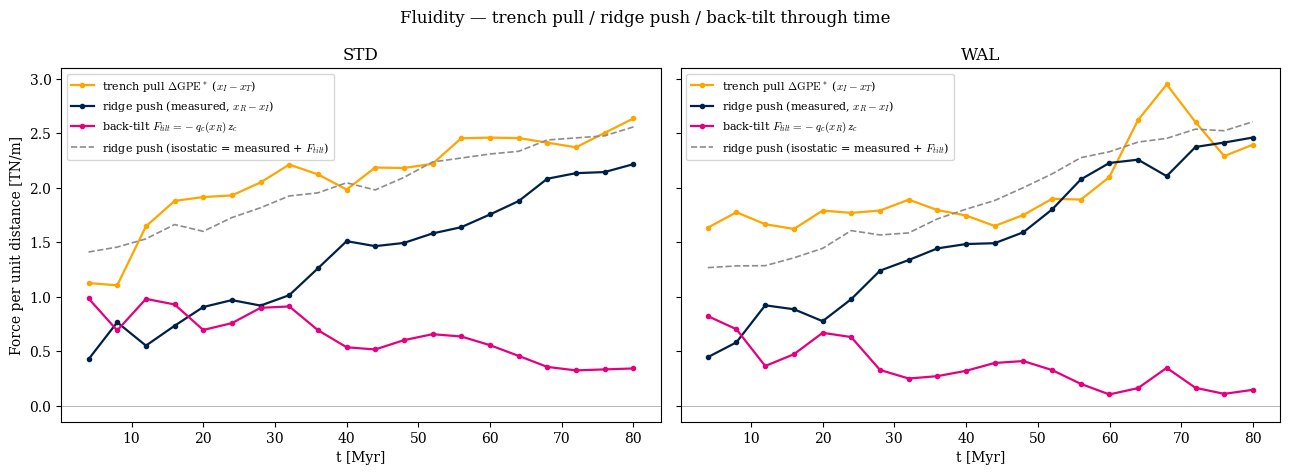

In [11]:
# Partition through time, one panel per model (STD | WAL), shared y-axis.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

for ax, (label, rec) in zip(axes, [("STD", records_STD), ("WAL", records_WAL)]):
    if rec is None:
        ax.set_visible(False)
        continue
    tM = rec["t_yr"] / 1e6
    tp = rec["delta_GPE"]                       # trench pull (x_I - x_T)
    rp = rec["delta_GPE_R"] - rec["delta_GPE"]  # measured ridge push (x_R - x_I)
    ft = rec["f_tilt"]
    ax.plot(tM, tp * 1e-12, ".-", color="orange", lw=1.6,
            label=r"trench pull $\Delta\mathrm{GPE}^*$ ($x_I - x_T$)")
    ax.plot(tM, rp * 1e-12, ".-", color="#002147", lw=1.6,
            label=r"ridge push (measured, $x_R - x_I$)")
    ax.plot(tM, ft * 1e-12, ".-", color="#E5007D", lw=1.6,
            label=r"back-tilt $F_{tilt} = -q_c(x_R)\,z_c$")
    ax.plot(tM, (rp + ft) * 1e-12, "--", color="0.55", lw=1.2,
            label="ridge push (isostatic = measured + $F_{tilt}$)")
    ax.axhline(0, color="0.6", lw=0.5)
    ax.set_xlabel("t [Myr]")
    ax.set_title(label)
    ax.legend(fontsize=8)
    print(f"{label}: run-median  trench pull {np.median(tp)*1e-12:+.2f}, "
          f"RP meas {np.median(rp)*1e-12:+.2f}, "
          f"F_tilt {np.median(ft)*1e-12:+.2f} TN/m, "
          f"suppression {np.median(ft / (rp + ft)):.2f}")

axes[0].set_ylabel("Force per unit distance [TN/m]")
fig.suptitle("Fluidity — trench pull / ridge push / back-tilt through time", fontsize=12)
fig.tight_layout()
out = figures_dir / "partition_back_tilt_time_series.png"
fig.savefig(out, dpi=160, bbox_inches="tight")
print("figure:", out)

### Why does the back-tilt change? The channel-flow test

If the return-flow pressure gradient obeys $\partial p/\partial x \sim \eta U / h^2$,
$F_{tilt}$ should track plate speed; channel thickening/warming would instead decay it
even at constant speed. The discriminating statistic is the correlation of
**step-to-step increments**, which is immune to shared secular trends. Verdict here:
the back-tilt is **velocity-following** — the $F_{tilt}$ series is close to a shifted
copy of $|v_{sp}|$, oscillation for oscillation, and WAL needs less pressure gradient
per unit speed (the weak layer). In dynamic-topography terms the ridge-end depression
$\Delta e = -q_c/\rho g$ is hundreds of metres, appearing and fading with plate speed
on ~10-Myr timescales.

STD: corr(|v_sp|, F_tilt) = +0.87   increments +0.91   slope 0.288 TN/m per cm/yr
WAL: corr(|v_sp|, F_tilt) = +0.63   increments +0.76   slope 0.110 TN/m per cm/yr


figure: figures/back_tilt_velocity_correlation.png


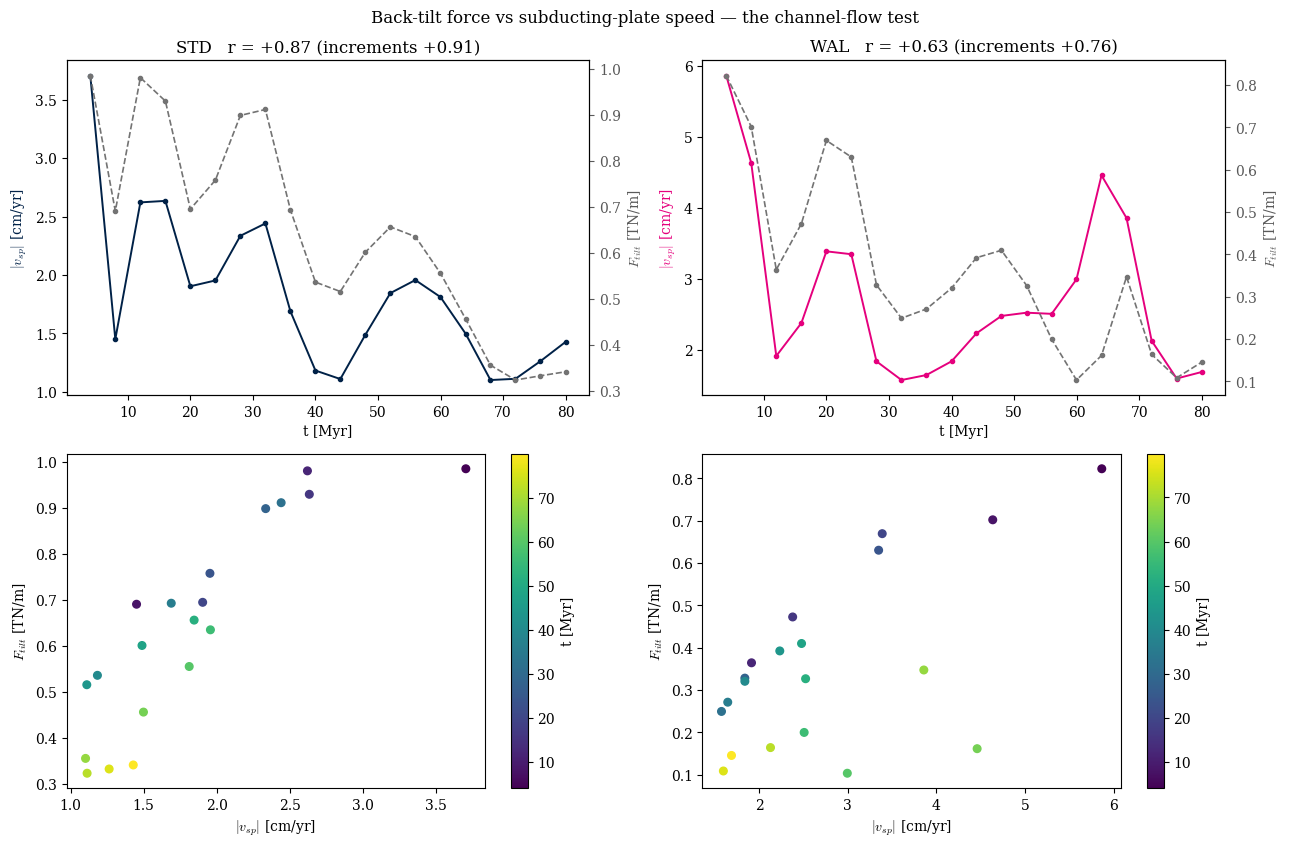

In [12]:
# F_tilt vs plate speed: twin time series + scatter, per model.
fig, axes = plt.subplots(2, 2, figsize=(13, 8.6))

for j, (label, rec, col) in enumerate([("STD", records_STD, "#002147"),
                                       ("WAL", records_WAL, "#E5007D")]):
    if rec is None:
        continue
    tM = rec["t_yr"] / 1e6
    u = np.abs(rec["v_sp"])            # numerically cm/yr (see loop note)
    ft = rec["f_tilt"] * 1e-12
    r_lvl = np.corrcoef(u, ft)[0, 1]
    r_inc = np.corrcoef(np.diff(u), np.diff(ft))[0, 1]
    print(f"{label}: corr(|v_sp|, F_tilt) = {r_lvl:+.2f}   increments {r_inc:+.2f}   "
          f"slope {np.polyfit(u, ft, 1)[0]:.3f} TN/m per cm/yr")

    ax = axes[0, j]
    ax.plot(tM, u, ".-", color=col, lw=1.4)
    ax.set_ylabel("$|v_{sp}|$ [cm/yr]", color=col)
    ax.set_xlabel("t [Myr]")
    ax.set_title(f"{label}   r = {r_lvl:+.2f} (increments {r_inc:+.2f})")
    ax2 = ax.twinx()
    ax2.plot(tM, ft, ".--", color="0.45", lw=1.2)
    ax2.set_ylabel("$F_{tilt}$ [TN/m]", color="0.35")
    ax2.tick_params(axis="y", colors="0.35")

    ax = axes[1, j]
    sc = ax.scatter(u, ft, c=tM, cmap="viridis", s=30)
    ax.set_xlabel("$|v_{sp}|$ [cm/yr]")
    ax.set_ylabel("$F_{tilt}$ [TN/m]")
    plt.colorbar(sc, ax=ax, label="t [Myr]")

fig.suptitle("Back-tilt force vs subducting-plate speed — the channel-flow test", fontsize=12)
fig.tight_layout()
out = figures_dir / "back_tilt_velocity_correlation.png"
fig.savefig(out, dpi=160, bbox_inches="tight")
print("figure:", out)

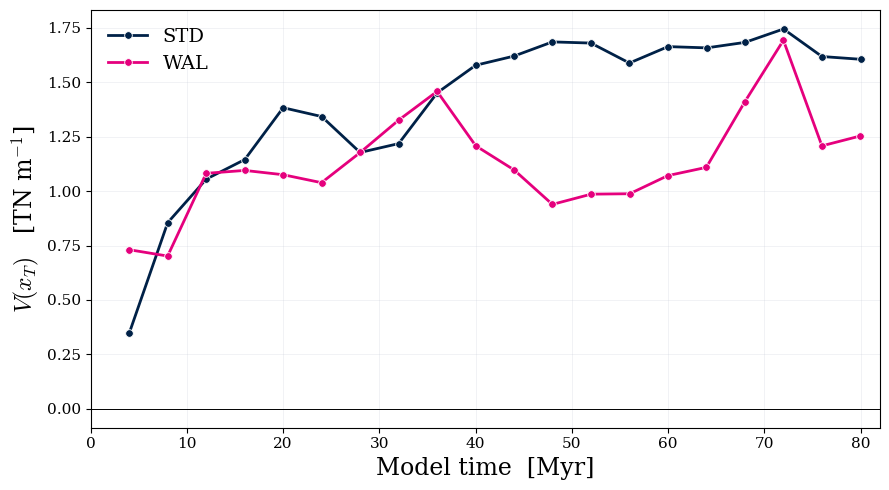

In [13]:
# V(x_T) time-series for STD and WAL — vertical shear stress resultant
# integrated through the column at the trench, plotted through model time.
figures_dir.mkdir(exist_ok=True)

# Brand model palette (single-quantity-per-model plot, so colour = model)
C_STD, C_WAL            = "#002147", "#E5007D"
C_SLATE, C_RULE, C_BAND = "#404B74", "#BFC3D1", "#F2F3F5"
models = [
    ("STD", C_STD, records_STD),
    ("WAL", C_WAL, records_WAL),
]

fig, ax = plt.subplots(figsize=(9, 5))

for label, color, rec in models:
    if rec is None:
        continue
    t_Myr = rec["t_yr"] / 1e6
    ax.plot(t_Myr, -1*rec["V_xT"] * 1e-12,
            "-o", color=color, lw=2.0, ms=5.5,
            markeredgecolor="white", markeredgewidth=0.6,
            label=label)

ax.axhline(0, color="k", lw=0.7)

ax.set_xlabel("Model time  [Myr]", fontsize=17)
ax.set_ylabel(r"$V(x_T)$   [TN m$^{-1}$]", fontsize=17)
ax.set_xlim(0, 82)
ax.legend(loc="best", frameon=False, fontsize=14)
ax.grid(True, alpha=0.25, color=C_RULE, lw=0.6)
ax.tick_params(labelsize=11)

fig.tight_layout()
fig.savefig(figures_dir / "V_xT_time_series.png",
            bbox_inches="tight", dpi=220)
plt.show()


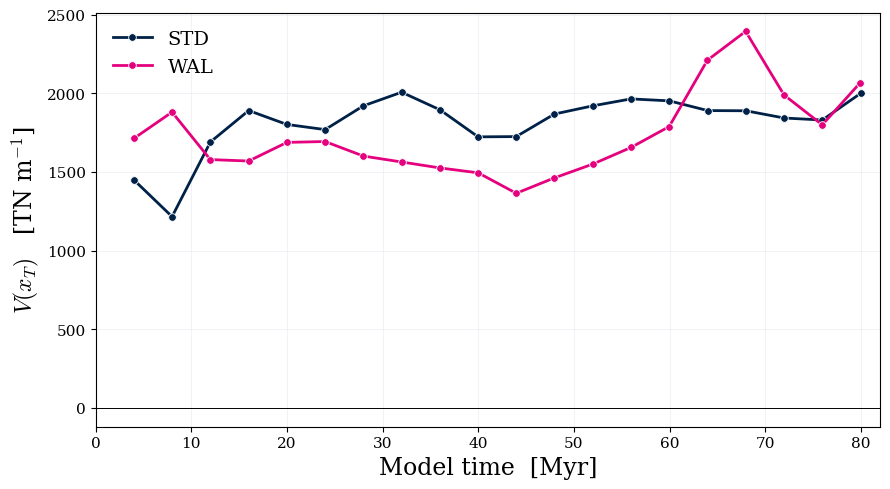

In [14]:
# V(x_T) time-series for STD and WAL — vertical shear stress resultant
# integrated through the column at the trench, plotted through model time.
figures_dir.mkdir(exist_ok=True)

# Brand model palette (single-quantity-per-model plot, so colour = model)
C_STD, C_WAL            = "#002147", "#E5007D"
C_SLATE, C_RULE, C_BAND = "#404B74", "#BFC3D1", "#F2F3F5"
models = [
    ("STD", C_STD, records_STD),
    ("WAL", C_WAL, records_WAL),
]

fig, ax = plt.subplots(figsize=(9, 5))

for label, color, rec in models:
    if rec is None:
        continue
    t_Myr = rec["t_yr"] / 1e6
    ax.plot(t_Myr, 1*rec["w_T"],
            "-o", color=color, lw=2.0, ms=5.5,
            markeredgecolor="white", markeredgewidth=0.6,
            label=label)

ax.axhline(0, color="k", lw=0.7)

ax.set_xlabel("Model time  [Myr]", fontsize=17)
ax.set_ylabel(r"$V(x_T)$   [TN m$^{-1}$]", fontsize=17)
ax.set_xlim(0, 82)
ax.legend(loc="best", frameon=False, fontsize=14)
ax.grid(True, alpha=0.25, color=C_RULE, lw=0.6)
ax.tick_params(labelsize=11)

fig.tight_layout()
fig.savefig(figures_dir / "V_xT_time_series.png",
            bbox_inches="tight", dpi=220)
plt.show()

In [15]:
#Asp = 40 My
VSP = 0.03
kmin80myr = VSP*1e6*80*1e-3
kmin80myr

2400.0

## 8. Example plots from the in-memory time-loop output

These plots use the in-memory `records` dict produced by §4 and reflect
whichever `MODEL_KEY` was last run.  Useful for quick exploration of a
single model — for slide-grade figures comparing STD and WAL, see §7.


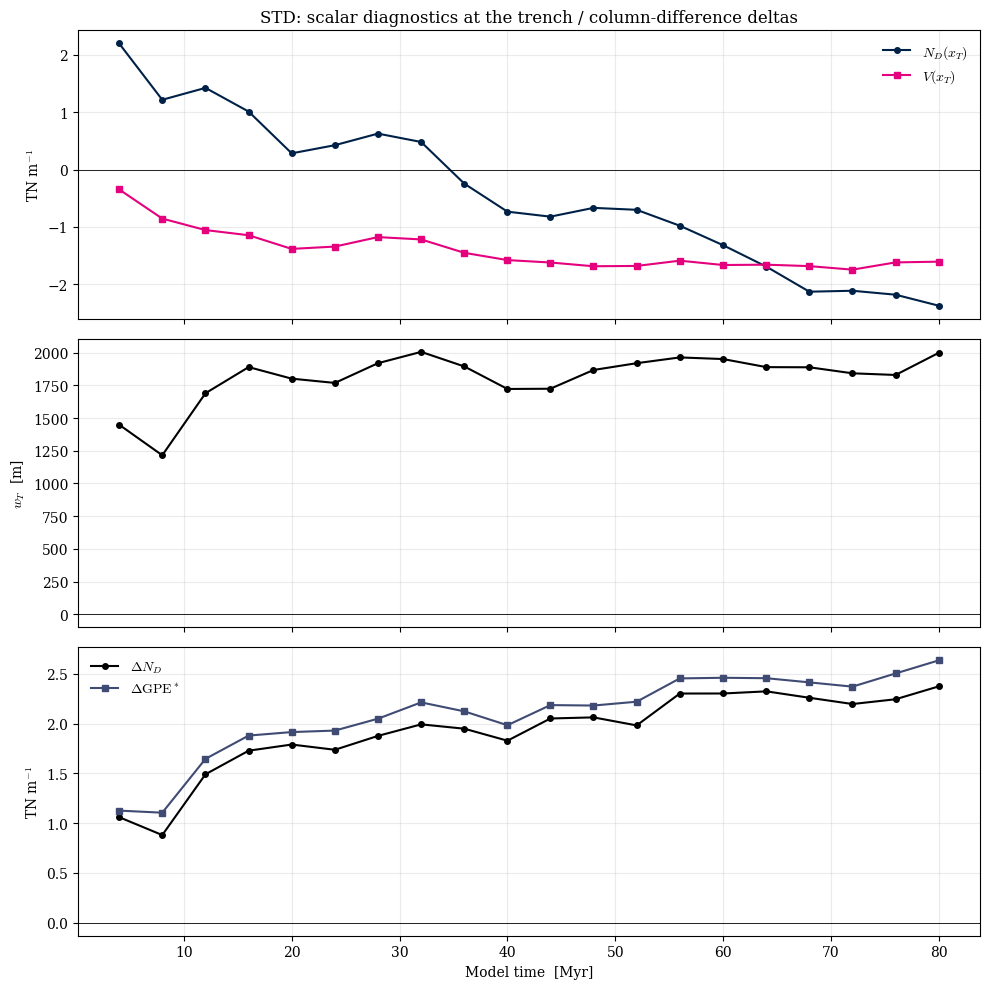

In [16]:
t_Myr = records['t_yr'] / 1e6

fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# (a) N_D and V at the trench
axs[0].plot(t_Myr, records['Fd_xT'] * 1e-12, '-o', color='#002147', ms=4, lw=1.5,
            label=r'$N_D(x_T)$')
axs[0].plot(t_Myr, records['V_xT']  * 1e-12, '-s', color='#E5007D', ms=4, lw=1.5,
            label=r'$V(x_T)$')
axs[0].axhline(0, color='k', lw=0.6)
axs[0].set_ylabel(r'TN m$^{-1}$')
axs[0].legend(frameon=False, loc='best')
axs[0].grid(alpha=0.25)
axs[0].set_title(f'{MODEL_KEY}: scalar diagnostics at the trench / column-difference deltas')

# (b) trench depression
axs[1].plot(t_Myr, records['w_T'], '-o', color='k', ms=4, lw=1.5)
axs[1].axhline(0, color='k', lw=0.6)
axs[1].set_ylabel(r'$w_T$  [m]')
axs[1].grid(alpha=0.25)

# (c) deltas (column differences x_I - x_T)
axs[2].plot(t_Myr, records['delta_Fd']  * 1e-12, '-o', color='k',       ms=4, lw=1.5,
            label=r'$\Delta N_D$')
axs[2].plot(t_Myr, records['delta_GPE'] * 1e-12, '-s', color='#404B74', ms=4, lw=1.5,
            label=r'$\Delta \mathrm{GPE}^*$')
axs[2].axhline(0, color='k', lw=0.6)
axs[2].set_ylabel(r'TN m$^{-1}$')
axs[2].set_xlabel('Model time  [Myr]')
axs[2].legend(frameon=False, loc='best')
axs[2].grid(alpha=0.25)

fig.tight_layout()
fig.savefig(figures_dir / f'time_evolution_scalars_{MODEL_KEY}.png',
            bbox_inches='tight', dpi=200)
plt.show()

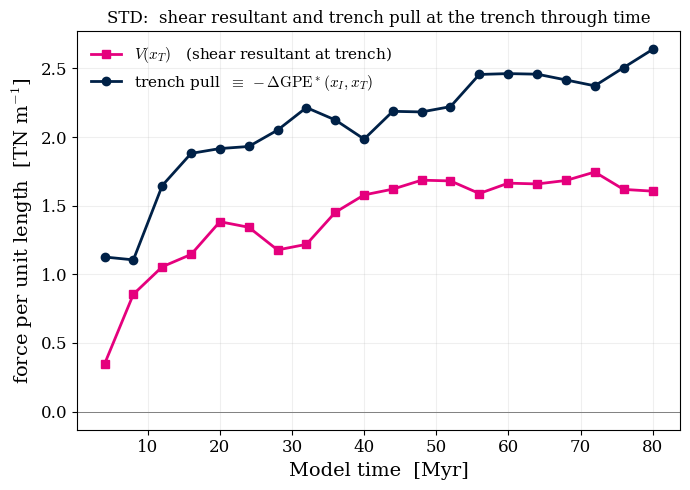

In [17]:
# Wrap-up slide figure: V(t) and trench pull at the trench column through time.
# Distilled from the 3-panel time-evolution figure: drops N_D(x_T), w_T,
# ΔF_D, and keeps only the two curves that land the slide's punchline —
# V(x_T) > 0 throughout (downward shear resultant), and the trench pull
# (= −\Delta\mathrm{GPE}^*) is positive and of order a few TN/m throughout.

t_Myr = records['t_yr'] / 1e6

fig, ax = plt.subplots(figsize=(7, 5))

# V at trench — positive throughout the run (the shear resultant on a plane
# beneath the trench, sense: downward into the asthenosphere).
ax.plot(t_Myr, -records['V_xT'] * 1e-12, '-s',
        color='#E5007D', ms=6, lw=2.0,
        label=r'$V(x_T)$   (shear resultant at trench)')

# Trench pull = -\Delta\mathrm{GPE}^*  (column-difference between x_T and x_I,
# equivalently Δσ̄_zz; relates to ΔP_T · h_np by the static scaling).
ax.plot(t_Myr, records['delta_GPE'] * 1e-12, '-o',
        color='#002147', ms=6, lw=2.0,
        label=r'trench pull  $\equiv\;-\Delta\mathrm{GPE}^*(x_I,x_T)$')

ax.axhline(0, color='0.5', lw=0.7)
ax.set_xlabel('Model time  [Myr]', fontsize=14)
ax.set_ylabel(r'force per unit length  [TN m$^{-1}$]', fontsize=14)
ax.legend(frameon=False, loc='upper left', fontsize=11)
ax.grid(alpha=0.20)
ax.tick_params(labelsize=12)

ax.set_title(f'{MODEL_KEY}:  shear resultant and trench pull at the trench through time',
             fontsize=12)

fig.tight_layout()
fig.savefig(figures_dir / f'V_dGPE_trench_time_{MODEL_KEY}.png',
            bbox_inches='tight', dpi=220)
plt.show()


In [18]:
#records["h_np"]

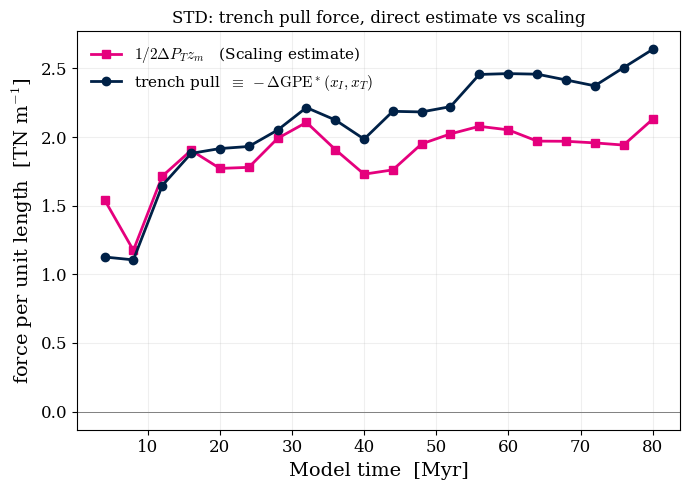

In [19]:
t_Myr = records['t_yr'] / 1e6

fig, ax = plt.subplots(figsize=(7, 5))

# V at trench — positive throughout the run (the shear resultant on a plane
# beneath the trench, sense: downward into the asthenosphere).
ax.plot(t_Myr, records['w_T']*records["h_np"]*3300*9.8 * 1e-12, '-s',
        color='#E5007D', ms=6, lw=2.0,
        label=r'$1/2\Delta P_T z_m$   (Scaling estimate)')

# Trench pull = -\Delta\mathrm{GPE}^*  (column-difference between x_T and x_I,
# equivalently Δσ̄_zz; relates to ΔP_T · h_np by the static scaling).
ax.plot(t_Myr, records['delta_GPE'] * 1e-12, '-o',
        color='#002147', ms=6, lw=2.0,
        label=r'trench pull  $\equiv\;-\Delta\mathrm{GPE}^*(x_I,x_T)$')

ax.axhline(0, color='0.5', lw=0.7)
ax.set_xlabel('Model time  [Myr]', fontsize=14)
ax.set_ylabel(r'force per unit length  [TN m$^{-1}$]', fontsize=14)
ax.legend(frameon=False, loc='upper left', fontsize=11)
ax.grid(alpha=0.20)
ax.tick_params(labelsize=12)

ax.set_title(f'{MODEL_KEY}: trench pull force, direct estimate vs scaling',
             fontsize=12)

fig.tight_layout()
fig.savefig(figures_dir / f'V_dGPE_trench_time_{MODEL_KEY}.png',
            bbox_inches='tight', dpi=220)
plt.show()


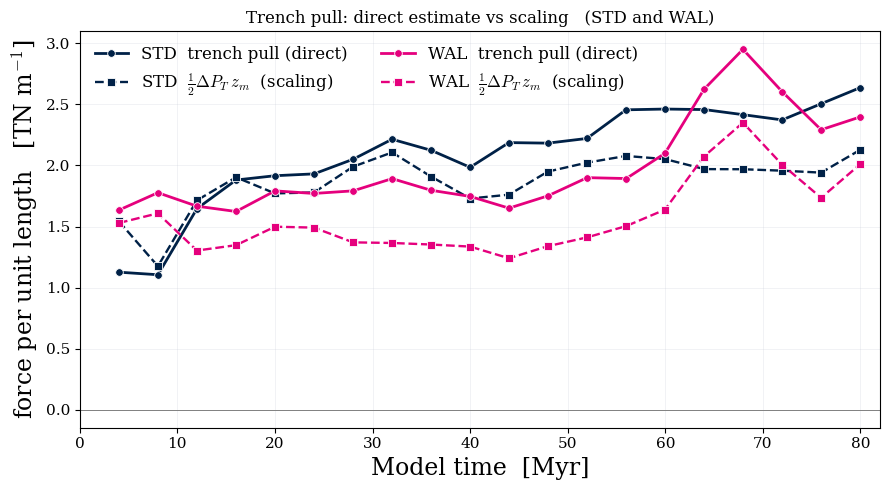

In [20]:
# Trench pull through time — direct estimate vs scaling estimate, for STD and WAL.
#
# Direct:    \Delta\mathrm{GPE}^*(x_I, x_T) = \mathrm{GPE}^*(x_I) - \mathrm{GPE}^*(x_T)              (records['delta_GPE'])
# Scaling:   ρ_m g w_T h_np  ≈  ΔP_T · h_np  ≈  ½ ΔP_T · z_m
#
# (with z_m ≈ 2 h_np, the "1/2 ΔP_T z_m" form is identical to the ΔP_T h_np form.)
figures_dir.mkdir(exist_ok=True)

C_STD, C_WAL            = "#002147", "#E5007D"
C_SLATE, C_RULE, C_BAND = "#404B74", "#BFC3D1", "#F2F3F5"

RHO_M, G = 3300.0, 9.8
models = [
    ("STD", C_STD, records_STD),
    ("WAL", C_WAL, records_WAL),
]

fig, ax = plt.subplots(figsize=(9, 5))

for label, color, rec in models:
    if rec is None:
        continue
    t_Myr = rec["t_yr"] / 1e6

    # Direct estimate — bold solid, the primary curve
    ax.plot(t_Myr, rec["delta_GPE"] * 1e-12,
            "-o", color=color, lw=2.0, ms=5.5,
            markeredgecolor="white", markeredgewidth=0.6,
            label=fr"{label}  trench pull (direct)")

    # Scaling estimate ρ_m g w_T h_np  =  ½ ΔP_T z_m
    ax.plot(t_Myr, rec["w_T"] * rec["h_np"] * RHO_M * G * 1e-12,
            "--s", color=color, lw=1.7, ms=5.5,
            markeredgecolor="white", markeredgewidth=0.6,
            label=fr"{label}  $\frac{{1}}{{2}}\Delta P_T\,z_m$  (scaling)")

ax.axhline(0, color="0.5", lw=0.7)

ax.set_xlabel("Model time  [Myr]", fontsize=17)
ax.set_ylabel(r"force per unit length   [TN m$^{-1}$]", fontsize=17)
ax.set_xlim(0, 82)
ax.legend(loc="upper left", frameon=False, fontsize=12, ncol=2)
ax.grid(True, alpha=0.25, color=C_RULE, lw=0.6)
ax.tick_params(labelsize=11)

ax.set_title("Trench pull: direct estimate vs scaling   (STD and WAL)",
             fontsize=12)

fig.tight_layout()
fig.savefig(figures_dir / "trench_pull_scaling_vs_direct_time_series.png",
            bbox_inches="tight", dpi=220)
plt.show()


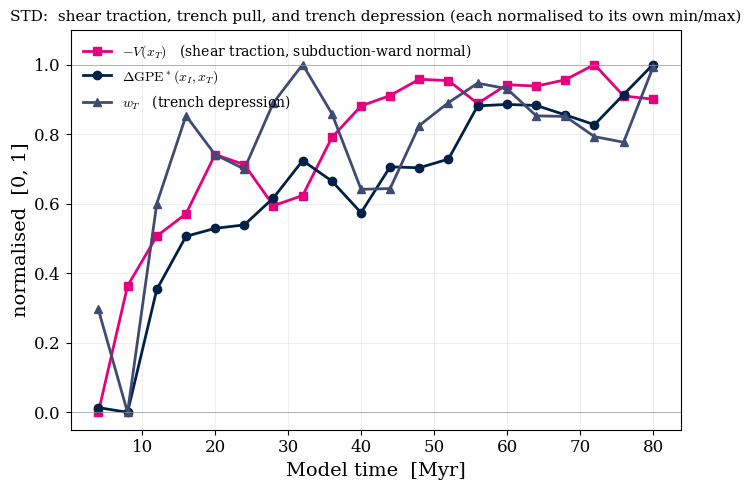

In [21]:
# Wrap-up slide figure (normalised version, sign-corrected):
# −V(t), \Delta\mathrm{GPE}^*(t), and trench depression w_T(t) — each rescaled
# linearly to [0, 1] over its own (min, max) range so the three
# curves are visually overlaid.
#
# Sign convention:
#   −V(x_T) — V multiplied by −1 to read as the shear traction on a
#             vertical plane whose outward normal points in the
#             subduction direction (subduction-ward = "left-negative").
#   \Delta\mathrm{GPE}^*   — column difference (x_I − x_T) plotted directly, no flip.
#   w_T     — trench-relative topography, naturally positive
#             (= fs[0, x_I] − fs[0, x_T]).

t_Myr = records['t_yr'] / 1e6

mV_norm = norm01(-records['V_xT'])           # shear traction, subduction-ward normal
GPE_norm = norm01(records['delta_GPE'])      # \Delta\mathrm{GPE}^* directly, no sign flip
wT_norm = norm01(records['w_T'])             # trench depression

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(t_Myr, mV_norm,  '-s', color='#E5007D', ms=6, lw=2.0,
        label=r'$-V(x_T)$   (shear traction, subduction-ward normal)')
ax.plot(t_Myr, GPE_norm, '-o', color='#002147', ms=6, lw=2.0,
        label=r'$\Delta\mathrm{GPE}^*(x_I,x_T)$')
ax.plot(t_Myr, wT_norm,  '-^', color='#404B74', ms=6, lw=2.0,
        label=r'$w_T$   (trench depression)')

ax.axhline(0, color='0.6', lw=0.5)
ax.axhline(1, color='0.6', lw=0.5)
ax.set_xlabel('Model time  [Myr]', fontsize=14)
ax.set_ylabel('normalised  [0, 1]', fontsize=14)
ax.set_ylim(-0.05, 1.10)
ax.legend(frameon=False, loc=2, fontsize=10)
ax.grid(alpha=0.20)
ax.tick_params(labelsize=12)

ax.set_title(f'{MODEL_KEY}:  shear traction, trench pull, and trench depression '
             f'(each normalised to its own min/max)',
             fontsize=11)

fig.tight_layout()
fig.savefig(figures_dir / f'wrapup_normalised_{MODEL_KEY}.png',
            bbox_inches='tight', dpi=220)
plt.show()


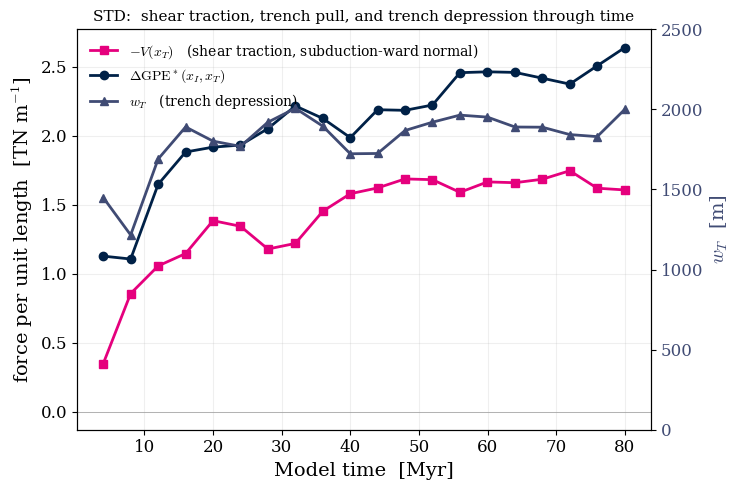

In [22]:
# Wrap-up slide figure (un-normalised, dual-axis):
#   left axis  — -V(x_T) and \Delta\mathrm{GPE}^*(x_I, x_T)  in TN/m
#   right axis — w_T  (trench depression)     in m
#
# Sign convention: V negated to read as the shear traction on a vertical
# plane with subduction-ward normal; \Delta\mathrm{GPE}^* and w_T plotted as recorded.

t_Myr = records['t_yr'] / 1e6

fig, ax = plt.subplots(figsize=(7.5, 5))
ax_r = ax.twinx()                    # right-hand axis for w_T

# Left axis — force per unit length (TN/m)
l1, = ax.plot(t_Myr, -records['V_xT']     * 1e-12, '-s',
              color='#E5007D', ms=6, lw=2.0,
              label=r'$-V(x_T)$   (shear traction, subduction-ward normal)')
l2, = ax.plot(t_Myr,  records['delta_GPE'] * 1e-12, '-o',
              color='#002147', ms=6, lw=2.0,
              label=r'$\Delta\mathrm{GPE}^*(x_I, x_T)$')

ax.axhline(0, color='0.6', lw=0.5)
ax.set_xlabel('Model time  [Myr]', fontsize=14)
ax.set_ylabel(r'force per unit length  [TN m$^{-1}$]', fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(alpha=0.20)

# Right axis — trench depression w_T (m)
l3, = ax_r.plot(t_Myr, records['w_T'], '-^',
                color='#404B74', ms=6, lw=2.0,
                label=r'$w_T$   (trench depression)')
ax_r.set_ylabel(r'$w_T$  [m]', fontsize=14, color='#404B74')
ax_r.tick_params(axis='y', labelsize=12, labelcolor='#404B74')
ax_r.set_ylim(0, 2500)

# Combined legend, upper-left
ax.legend(handles=[l1, l2, l3], frameon=False,
          loc='upper left', fontsize=10)

ax.set_title(f'{MODEL_KEY}:  shear traction, trench pull, and trench depression through time',
             fontsize=11)

fig.tight_layout()
fig.savefig(figures_dir / f'wrapup_dual_axis_{MODEL_KEY}.png',
            bbox_inches='tight', dpi=220)
plt.show()


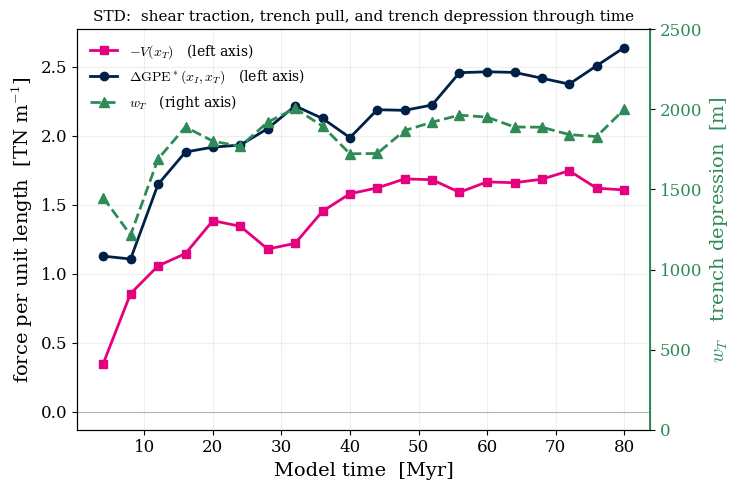

In [23]:
# Wrap-up slide figure (un-normalised, dual-axis) — visual rules to flag
# left- vs right-axis quantities at a glance:
#
#   * Left  axis  (force per unit length, TN/m): SOLID lines, square/circle
#                                                markers, "force" colours.
#   * Right axis  (topography, m):              DASHED line, triangle marker,
#                                                a distinct sea-green colour
#                                                that doesn't share the
#                                                navy/slate family.
#   * Right axis label, ticks, and spine all coloured to match the curve.
#   * Legend labels carry explicit "(left)" / "(right)" tags.
#
# Sign convention unchanged: V negated; \Delta\mathrm{GPE}^* and w_T plotted as recorded.

t_Myr = records['t_yr'] / 1e6

# Palette — left-axis force curves stay in the brand navy/magenta family;
# right-axis topography curve gets a distinct sea green.
COLOR_V    = '#E5007D'   # magenta — left axis (force)
COLOR_GPE  = '#002147'   # navy    — left axis (force)
COLOR_WT   = '#2E8B57'   # sea green — right axis (topography)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax_r = ax.twinx()

# --- Left axis: force resultants (solid, square/circle) -------------------
l1, = ax.plot(t_Myr, -records['V_xT']     * 1e-12, '-s',
              color=COLOR_V,   ms=6, lw=2.0)
l2, = ax.plot(t_Myr,  records['delta_GPE'] * 1e-12, '-o',
              color=COLOR_GPE, ms=6, lw=2.0)

ax.axhline(0, color='0.6', lw=0.5)
ax.set_xlabel('Model time  [Myr]', fontsize=14)
ax.set_ylabel(r'force per unit length  [TN m$^{-1}$]', fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(alpha=0.20)

# --- Right axis: trench topography (dashed, triangle, sea green) ---------
l3, = ax_r.plot(t_Myr, records['w_T'], '--^',
                color=COLOR_WT, ms=7, lw=2.0)

ax_r.set_ylabel(r'$w_T$   trench depression  [m]',
                fontsize=14, color=COLOR_WT)
ax_r.tick_params(axis='y', labelsize=12, labelcolor=COLOR_WT)
ax_r.spines['right'].set_color(COLOR_WT)
ax_r.spines['right'].set_linewidth(1.4)
ax_r.set_ylim(0, 2500)

# --- Combined legend (upper left) with explicit axis tags ----------------
ax.legend(
    handles=[l1, l2, l3],
    labels=[
        r'$-V(x_T)$   (left axis)',
        r'$\Delta\mathrm{GPE}^*(x_I, x_T)$   (left axis)',
        r'$w_T$   (right axis)',
    ],
    loc='upper left', frameon=False, fontsize=10,
)

ax.set_title(f'{MODEL_KEY}:  shear traction, trench pull, and trench depression through time',
             fontsize=11)

fig.tight_layout()
fig.savefig(figures_dir / f'wrapup_dual_axis_{MODEL_KEY}.png',
            bbox_inches='tight', dpi=220)
plt.show()


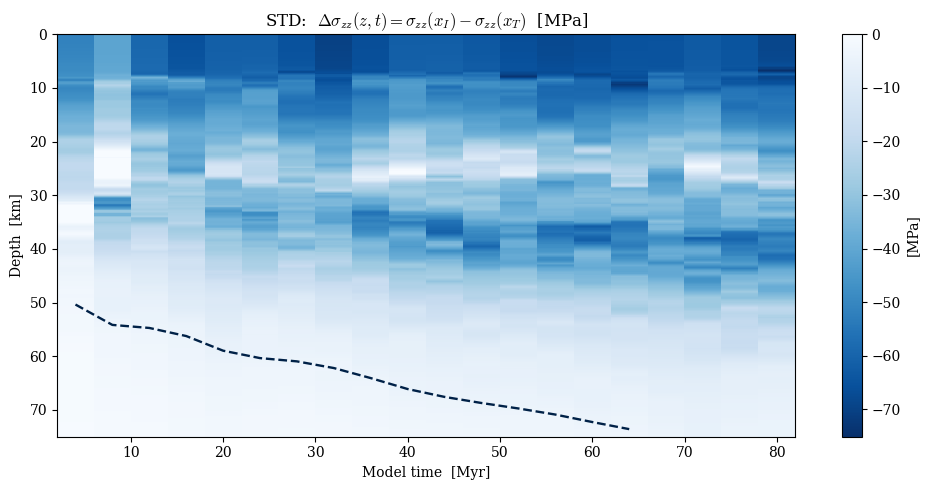

In [24]:
# Δσ_zz(z, t) — depth-by-time heat map
fig, ax = plt.subplots(figsize=(10, 5))
vmax = np.nanmax(np.abs(delta_sig_zz_zt)) * 1e-6
im = ax.pcolormesh(t_Myr, z_axis * 1e-3, delta_sig_zz_zt.T * 1e-6,
                   shading='auto', cmap='Blues_r', vmin=-vmax, vmax=0)

ax.plot(records['t_yr'] / 1e6, records['z_iso'] * 1e-3,
        '--', color='#002147', ms=5, lw=1.7, label="depth T_900")

ax.invert_yaxis()
ax.set_xlabel('Model time  [Myr]')
ax.set_ylabel('Depth  [km]')
ax.set_title(rf'{MODEL_KEY}:  $\Delta \sigma_{{zz}}(z, t) = \sigma_{{zz}}(x_I) - \sigma_{{zz}}(x_T)$  [MPa]')
fig.colorbar(im, ax=ax, label='[MPa]')
fig.tight_layout()
fig.savefig(figures_dir / f'time_evolution_dsigzz_{MODEL_KEY}.png',
            bbox_inches='tight', dpi=200)

#ax.set
plt.show()

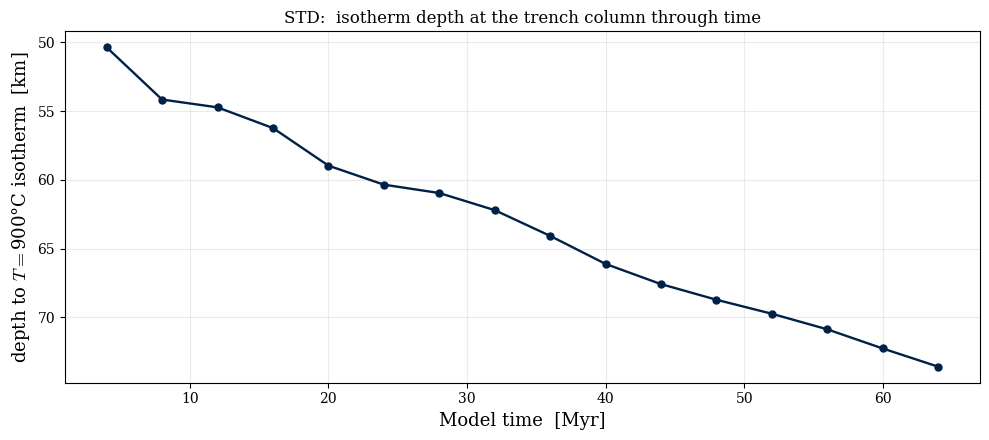

In [25]:
# Depth to the T_ISO isotherm at the trench column over time.
# Tracks how the thermal lithosphere thickness evolves under the trench.

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(records['t_yr'] / 1e6, records['z_iso'] * 1e-3,
        '-o', color='#002147', ms=5, lw=1.7)
ax.invert_yaxis()
ax.set_xlabel('Model time  [Myr]', fontsize=13)
ax.set_ylabel(f'depth to $T = ${T_ISO_K-273.15:.0f}°C isotherm  [km]', fontsize=13)
ax.set_title(f'{MODEL_KEY}:  isotherm depth at the trench column through time')
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(figures_dir / f'time_evolution_z_iso_{MODEL_KEY}.png',
            bbox_inches='tight', dpi=200)
plt.show()


## 9. Per-snapshot force-balance plots

Generates a §9.2-style two-panel figure (free surface + force balance
$\Delta N_D - \Delta\mathrm{GPE}^* + F_B$) at every PVTU snapshot.  Output
frames go to a model-keyed subdirectory `figures/force_balance_evolution_<MODEL_KEY>/`
to avoid filling the main figures directory.  Set `PVTU_STRIDE > 1` to subsample.


In [26]:
DX =1000
SMOOTHWIN = 1

In [27]:
from scipy.integrate import cumulative_trapezoid

# ----- output dir + loop config ------------------------------------------
OUT_DIR = Path('figures') / f'force_balance_evolution_{MODEL_KEY}'
OUT_DIR.mkdir(parents=True, exist_ok=True)

PVTU_STRIDE      = 1     # 1 = every snapshot; 2 = every other; etc.
TRENCH_REF_HW_KM = 5
WIN_T_FB         = max(1, int(TRENCH_REF_HW_KM * 1000 / DX))

# Constants used in the plot block
rho_m_local, g_local = 3300.0, 9.8

n_saved = 0
for i in range(0, len(pvtu_files), PVTU_STRIDE):
    if i == 0:
        continue                                   # skip initial-condition snapshot
    ff = pvtu_files[i]

    # --- Read PVTU and stash named fields --------------------------------
    vtk_data = pv.read(ff)
    vtk_data.point_data['p']   = vtk_data['NormalSP::Pressure']
    vtk_data.point_data['txx'] = vtk_data['NormalSP::Stress'][:, 0]
    vtk_data.point_data['tzz'] = vtk_data['NormalSP::Stress'][:, 4]
    vtk_data.point_data['txz'] = -vtk_data['NormalSP::Stress'][:, 1]
    vtk_data.point_data['T']   = vtk_data['NormalSP::Temperature']
    vtk_data.point_data['fs']  = vtk_data['NormalSP::FreeSurface']
    vel = vtk_data['NormalSP::Velocity'] / 3.17098e-10
    vtk_data.point_data['vx']  = vel[:, 0]
    vtk_data.point_data['vy']  = vel[:, 1]

    t_yr = float(np.asarray(vtk_data['NormalSP::Time']).flat[0]) / 31_557_600.0

    # --- Build grid + interpolate ----------------------------------------
    x_min, x_max, _, _, _, _ = vtk_data.bounds
    nx = int((x_max - x_min) / DX); nz = int(Z_MAX / DX)
    x = x_min + (np.arange(nx) + 0.5) * DX
    z = (np.arange(nz) + 0.5) * DX
    X, Z = np.meshgrid(x, z, indexing='xy')
    Y = Y_SURFACE - Z
    grid = pv.StructuredGrid(X.T, Y.T, np.zeros_like(X.T))
    interp = grid.sample(vtk_data)
    nx_pv, nz_pv, _ = interp.dimensions
    valid = interp['vtkValidPointMask'].reshape((nx_pv, nz_pv), order='F').astype(bool)
    get_field = make_field_extractor(interp, nx_pv, nz_pv, valid)

    p   = get_field('p')
    txx = get_field('txx')
    tzz = get_field('tzz')
    txz = get_field('txz')
    T   = get_field('T')
    fs  = get_field('fs')
    vx  = get_field('vx')
    vz  = -get_field('vy')

    if MIRROR_X:
        p, txx, tzz, txz, T, fs, vx, vz = mirror_fields_in_x(p, txx, tzz, txz, T, fs, vx, vz)

    # --- Trench picker + first isostatic column --------------------------
    try:
        x_trench, _ = pick_trench_3step(
            x, z, p, vx,
            vx_depth_m=2000, Wp1_km=800, Wv_km=800, Wp3_km=500,
            smooth_km=30, subducting_side=SUBDUCTING_SIDE,
        )
    except Exception as e:
        print(f'  [{i}] picker failed: {e}; skipping')
        plt.close('all')
        continue
    tindx = int(np.argmin(np.abs(x - x_trench)))

    xi_indx, _ = find_first_isostatic_column(
        x, fs[0, :], x_trench, tindx, DX,
        buffer_km=BUFFER_KM, window_km=WINDOW_KM,
        regional_ref_km=REGIONAL_REF_KM, seaward_sign=SEAWARD_SIGN,
    )
    xi_loc = float(x[xi_indx])

    # --- Resultants -------------------------------------------------------
    Fd   = np.trapz(txx - tzz, z, axis=0)
    Sxx  = np.trapz(-p + txx, z, axis=0)
    Szz  = np.trapz(-p + tzz, z, axis=0)
    V    = np.trapz(txz, z, axis=0)
    dVdx = np.gradient(V, x)

    tau_b = txz[-1, :]
    FB_   = cumulative_trapezoid(tau_b, x, initial=0.0)
    FB    = FB_ - FB_[tindx]

    delta_Fd  = Fd  - col_avg(Fd,  tindx, win=WIN_T_FB)
    delta_Szz = Szz - col_avg(Szz, tindx, win=WIN_T_FB)

    # --- Plot -------------------------------------------------------------
    xkm = (x - x_trench) * 1e-3
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True,
                                    gridspec_kw={'height_ratios': [1.25, 2]})

    # Top: free surface (positive = downward)
    ax1.plot(xkm, -fs[0, :], color='k', lw=1.5, label='$w$')
    ax1.axhline(0, color='k', lw=0.5)
    ax1.axvline(0, color='k', lw=0.5)
    ax1.axvline((xi_loc - x_trench)*1e-3, color='k', lw=0.5)
    ax1.set_ylim(2500, -1500)
    ax1.set_ylabel('$w$ [m] (positive downward)', fontsize=14)
    ax1.legend(loc='lower right', fontsize=12)
    ax1.set_title(f'{MODEL_KEY},  $t = {t_yr/1e6:.1f}$ Myr\n'
                  r'trailing-plate force balance', fontsize=15)

    # Bottom: ΔF_D − \Delta\mathrm{GPE}^* + F_B
    ax2.plot(xkm, FB         * 1e-12, color='red', lw=2,
             label=r'$F_B(x)$')
    ax2.plot(xkm, delta_Fd   * 1e-12, color='k', ls='--', lw=2,
             label=r'$\Delta N_D(x)$')
    ax2.plot(xkm, -delta_Szz * 1e-12, color='b', lw=2,
             label=r'$\Delta\mathrm{GPE}^*(x)$')
    ax2.plot(xkm, (delta_Fd + delta_Szz + FB) * 1e-12,
             color='g', ls='--', lw=3,
             label=r'$\Delta N_D - \Delta\mathrm{GPE}^* + F_B$')
    ax2.axhline(0, color='k', lw=0.5)
    ax2.axvline(0, color='k', lw=0.5)
    ax2.axvline((xi_loc - x_trench)*1e-3, color='k', lw=0.5)
    ax2.set_xlabel('Distance from trench [km]', fontsize=14)
    ax2.set_ylabel('Force per unit distance [TN/m]', fontsize=14)
    ax2.set_xlim(-20, 4000)
    ax2.set_ylim(-2.5, 4.0)

    fig.tight_layout()

    fn = OUT_DIR / f'force_balance_{MODEL_KEY}_t{i:03d}.png'
    fig.savefig(fn, bbox_inches='tight', dpi=150)
    plt.close(fig)

    n_saved += 1

    # Cleanup
    del vtk_data, grid, interp, X, Y, Z, p, txx, tzz, txz, T, fs, vx, vz
    if i % 5 == 0:
        gc.collect()
        print(f'  [{i:>3}]  t = {t_yr/1e6:6.2f} Myr  ->  {fn.name}')

print(f'\nsaved {n_saved} frames to {OUT_DIR}')


  [  5]  t =  10.02 Myr  ->  force_balance_STD_t005.png


  [ 10]  t =  20.00 Myr  ->  force_balance_STD_t010.png


  [ 15]  t =  29.98 Myr  ->  force_balance_STD_t015.png


  [ 20]  t =  40.00 Myr  ->  force_balance_STD_t020.png


  [ 25]  t =  50.01 Myr  ->  force_balance_STD_t025.png


  [ 30]  t =  59.98 Myr  ->  force_balance_STD_t030.png


  [ 35]  t =  69.97 Myr  ->  force_balance_STD_t035.png


  [ 40]  t =  80.00 Myr  ->  force_balance_STD_t040.png

saved 40 frames to figures/force_balance_evolution_STD


In [28]:
#records

In [29]:
records['z_iso']

array([50370.79813612, 54166.11293534, 54735.00193072, 56243.96140759,
       58969.74660831, 60352.92644235, 60959.40892668, 62203.67437927,
       64078.69211597, 66113.97182218, 67574.75814127, 68710.51478789,
       69730.50114853, 70861.51671443, 72258.24823195, 73585.97117805,
                  nan,            nan,            nan,            nan])

In [30]:
# Per-snapshot force-balance loop — §8.3 (re-referenced, absolute N_D).
#
# Drop this into a fresh code cell in cerpa_time_evolution.ipynb after the
# existing §7 fb-movie cell.  Same per-snapshot pipeline, but plotted in
# the form
#
#   N_D(x)  -  [\Delta\mathrm{GPE}^*(x) + N_D(x_T)]  +  F_B(x)  ~  0
#
# so N_D appears at its absolute value and the GPE bracket carries the
# trench-column N_D(x_T) as an offset.  Algebraically identical to §7.
# Frames go to a separate subdirectory so the §7 frames aren't overwritten.

from scipy.integrate import cumulative_trapezoid

# ----- output dir + loop config ------------------------------------------
OUT_DIR_ABS = Path('figures') / f'force_balance_FD_abs_evolution_{MODEL_KEY}'
OUT_DIR_ABS.mkdir(parents=True, exist_ok=True)

PVTU_STRIDE_ABS      = 1
TRENCH_REF_HW_KM_ABS = 5
WIN_T_ABS            = max(1, int(TRENCH_REF_HW_KM_ABS * 1000 / DX))

n_saved = 0
for i in range(0, len(pvtu_files), PVTU_STRIDE_ABS):
    if i == 0:
        continue
    ff = pvtu_files[i]

    # --- Read PVTU + stash named fields ---------------------------------
    vtk_data = pv.read(ff)
    vtk_data.point_data['p']   = vtk_data['NormalSP::Pressure']
    vtk_data.point_data['txx'] = vtk_data['NormalSP::Stress'][:, 0]
    vtk_data.point_data['tzz'] = vtk_data['NormalSP::Stress'][:, 4]
    vtk_data.point_data['txz'] = -vtk_data['NormalSP::Stress'][:, 1]
    vtk_data.point_data['T']   = vtk_data['NormalSP::Temperature']
    vtk_data.point_data['fs']  = vtk_data['NormalSP::FreeSurface']
    vel = vtk_data['NormalSP::Velocity'] / 3.17098e-10
    vtk_data.point_data['vx']  = vel[:, 0]
    vtk_data.point_data['vy']  = vel[:, 1]

    t_yr = float(np.asarray(vtk_data['NormalSP::Time']).flat[0]) / 31_557_600.0

    # --- Grid + interpolate ---------------------------------------------
    x_min, x_max, _, _, _, _ = vtk_data.bounds
    nx = int((x_max - x_min) / DX); nz = int(Z_MAX / DX)
    x = x_min + (np.arange(nx) + 0.5) * DX
    z = (np.arange(nz) + 0.5) * DX
    X, Z = np.meshgrid(x, z, indexing='xy')
    Y = Y_SURFACE - Z
    grid = pv.StructuredGrid(X.T, Y.T, np.zeros_like(X.T))
    interp = grid.sample(vtk_data)
    nx_pv, nz_pv, _ = interp.dimensions
    valid = interp['vtkValidPointMask'].reshape((nx_pv, nz_pv), order='F').astype(bool)
    get_field = make_field_extractor(interp, nx_pv, nz_pv, valid)   # BUGFIX: was reusing a stale closure -> frozen fields

    p   = get_field('p')
    txx = get_field('txx')
    tzz = get_field('tzz')
    txz = get_field('txz')
    T   = get_field('T')
    fs  = get_field('fs')
    vx  = get_field('vx')
    vz  = -get_field('vy')

    if MIRROR_X:
        p, txx, tzz, txz, T, fs, vx, vz = mirror_fields_in_x(p, txx, tzz, txz, T, fs, vx, vz)

    # --- Picker + first isostatic column --------------------------------
    try:
        x_trench, _ = pick_trench_3step(
            x, z, p, vx,
            vx_depth_m=2000, Wp1_km=800, Wv_km=800, Wp3_km=500,
            smooth_km=30, subducting_side=SUBDUCTING_SIDE,
        )
    except Exception as e:
        print(f'  [{i}] picker failed: {e}; skipping')
        plt.close('all')
        continue
    tindx = int(np.argmin(np.abs(x - x_trench)))

    xi_indx, _ = find_first_isostatic_column(
        x, fs[0, :], x_trench, tindx, DX,
        buffer_km=BUFFER_KM, window_km=WINDOW_KM,
        regional_ref_km=REGIONAL_REF_KM, seaward_sign=SEAWARD_SIGN,
    )
    xi_loc = float(x[xi_indx])

    # --- Resultants -----------------------------------------------------
    Fd   = np.trapz(txx - tzz, z, axis=0)
    Szz  = np.trapz(-p + tzz, z, axis=0)

    tau_b = txz[-1, :]
    FB_   = cumulative_trapezoid(tau_b, x, initial=0.0)
    FB    = FB_ - FB_[tindx]

    # §8.3 form: N_D(x) absolute; GPE bracket carries N_D(x_T)
    delta_Fd  = Fd                                                          # = N_D(x)
    delta_Szz = (Szz
                 - col_avg(Szz, tindx, win=WIN_T_ABS)
                 - col_avg(Fd,  tindx, win=WIN_T_ABS))                      # = -[\Delta\mathrm{GPE}^* + N_D(x_T)]

    # --- Plot -----------------------------------------------------------
    xkm = (x - x_trench) * 1e-3
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True,
                                    gridspec_kw={'height_ratios': [1.25, 2]})

    # Top: free surface (positive = downward)
    ax1.plot(xkm, -fs[0, :], color='k', lw=1.5, label='$w$')
    ax1.axhline(0, color='k', lw=0.5)
    ax1.axvline(0, color='k', lw=0.5)
    ax1.axvline((xi_loc - x_trench)*1e-3, color='k', lw=0.5)
    ax1.set_ylim(2500, -1500)
    ax1.set_ylabel('$w$ [m] (positive downward)', fontsize=14)
    ax1.legend(loc='lower right', fontsize=12)
    ax1.set_title(f'{MODEL_KEY},  $t = {t_yr/1e6:.1f}$ Myr\n'
                  r'trailing-plate force balance:  '
                  r'$N_D(x) - [\Delta\mathrm{GPE}^*(x) + N_D(x_T)] + F_B(x) \approx 0$',
                  fontsize=13)

    # Bottom: N_D(x) − [\Delta\mathrm{GPE}^*(x) + N_D(x_T)] + F_B(x)
    ax2.plot(xkm, FB         * 1e-12, color='red', lw=2,
             label=r'$F_B(x)$')
    ax2.plot(xkm, delta_Fd   * 1e-12, color='k', ls='--', lw=2,
             label=r'$N_D(x)$')
    ax2.plot(xkm, -delta_Szz * 1e-12, color='b', lw=2,
             label=r'$\Delta\mathrm{GPE}^*(x) + N_D(x_T)$')
    ax2.plot(xkm, (delta_Fd + delta_Szz + FB) * 1e-12,
             color='g', ls='--', lw=3,
             label=r'$N_D - [\Delta\mathrm{GPE}^* + N_D(x_T)] + F_B$')
    ax2.axhline(0, color='k', lw=0.5)
    ax2.axvline(0, color='k', lw=0.5)
    ax2.axvline((xi_loc - x_trench)*1e-3, color='k', lw=0.5)
    ax2.set_xlabel('Distance from trench [km]', fontsize=14)
    ax2.set_ylabel('Force per unit distance [TN/m]', fontsize=14)
    ax2.set_xlim(-20, 4000)
    ax2.set_ylim(-5.0, 5.0)
    ax2.legend(loc='lower right', fontsize=11, ncol=2)

    fig.tight_layout()

    fn = OUT_DIR_ABS / f'force_balance_FD_abs_{MODEL_KEY}_t{i:03d}.png'
    fig.savefig(fn, bbox_inches='tight', dpi=150)
    plt.close(fig)

    n_saved += 1

    del vtk_data, grid, interp, X, Y, Z, p, txx, tzz, txz, T, fs, vx, vz
    if i % 5 == 0:
        gc.collect()
        print(f'  [{i:>3}]  t = {t_yr/1e6:6.2f} Myr  ->  {fn.name}')

print(f'\nsaved {n_saved} frames to {OUT_DIR_ABS}')


  [  5]  t =  10.02 Myr  ->  force_balance_FD_abs_STD_t005.png


  [ 10]  t =  20.00 Myr  ->  force_balance_FD_abs_STD_t010.png


  [ 15]  t =  29.98 Myr  ->  force_balance_FD_abs_STD_t015.png


  [ 20]  t =  40.00 Myr  ->  force_balance_FD_abs_STD_t020.png


  [ 25]  t =  50.01 Myr  ->  force_balance_FD_abs_STD_t025.png


  [ 30]  t =  59.98 Myr  ->  force_balance_FD_abs_STD_t030.png


  [ 35]  t =  69.97 Myr  ->  force_balance_FD_abs_STD_t035.png


  [ 40]  t =  80.00 Myr  ->  force_balance_FD_abs_STD_t040.png

saved 40 frames to figures/force_balance_FD_abs_evolution_STD


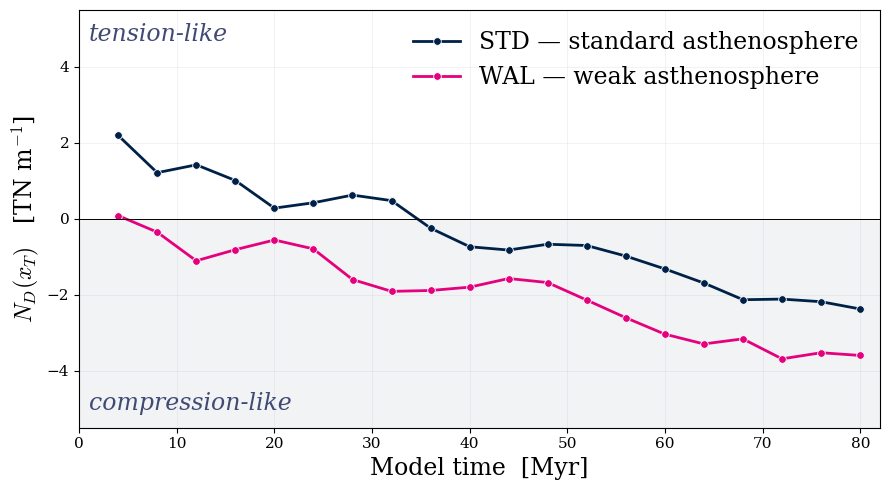

In [31]:
# N_D(x_T) time-series, plotting both STD and WAL on shared axes.
# Sources data from the time-evolution notebook's npz cache so the single-step
# notebook isn't needed for this figure.
#
# Expects (re-run the time loop with MODEL_KEY = "STD" and MODEL_KEY = "WAL"):
#   outputs/time_evolution_STD.npz
#   outputs/time_evolution_WAL.npz
outputs_dir = Path("outputs")   # was only ever defined interactively
figures_dir.mkdir(exist_ok=True)

# Brand palette (matches presentation/theme.scss)
C_STD, C_WAL = "#002147", "#E5007D"
C_SLATE, C_RULE, C_BAND = "#404B74", "#BFC3D1", "#F2F3F5"

fig, ax = plt.subplots(figsize=(9, 5))

for key, color, label in [("STD", C_STD, "STD — standard asthenosphere"),
                          ("WAL", C_WAL, "WAL — weak asthenosphere")]:
    npz_path = outputs_dir / f"time_evolution_{key}.npz"
    if not npz_path.exists():
        print(f"⚠  {npz_path.name} not found — re-run the time-evolution loop "
              f"with MODEL_KEY = {key!r}")
        continue
    d      = np.load(npz_path)
    t_Myr  = d["t_yr"] / 1e6
    Fd_TNm = d["Fd_xT"] * 1e-12
    ax.plot(t_Myr, Fd_TNm, "-o",
            color=color, lw=2.0, ms=5.5,
            markeredgecolor="white", markeredgewidth=0.6, label=label)

ax.axhline(0, color="k", lw=0.7)
ax.axhspan(-100, 0, color=C_BAND, zorder=-2)
ax.text(0.012, 0.97, "tension-like", transform=ax.transAxes,
        ha="left", va="top", fontsize=17, color=C_SLATE, style="italic")
ax.text(0.012, 0.03, "compression-like", transform=ax.transAxes,
        ha="left", va="bottom", fontsize=17, color=C_SLATE, style="italic")

ax.set_xlabel("Model time  [Myr]", fontsize=17)
ax.set_ylabel(r"$N_D(x_T)$   [TN m$^{-1}$]", fontsize=17)
ax.set_xlim(0, 82)
ax.set_ylim(-5.5, 5.5)
ax.legend(loc="upper right", frameon=False, fontsize=17)
ax.grid(True, alpha=0.25, color=C_RULE, lw=0.6)
ax.tick_params(labelsize=11)

fig.tight_layout()
fig.savefig(figures_dir / "Fd_xT_time_series.png", bbox_inches="tight", dpi=220)
plt.show()


In [32]:
 from scipy.ndimage import gaussian_filter